### ***PROJET: ANALYSE DE LA PERFORMANCE D'OLIST***

### ***Indices de performance globale défini***

In [ ]:
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

### ***REFERENCE***

| Dimension | KPI principaux | Pondération | Impact |
|-----------|----------------|-------------|--------|
| **Commercial (Ventes)** | • Chiffre d'affaires total<br>• Chiffre d'affaires mensuel<br>• Chiffre d'affaires journalier<br>• Nombre total de commandes<br>• Nombre total de produits vendus<br>• Panier moyen global<br>• Nombre de commandes annulées<br>• Nombre de commandes en stock indisponible<br>• Nombre de commandes livrées en retard | • CA : 20%<br>• CA mensuel : 10%<br>• CA journalier : 10%<br>• Nbre commandes : 10%<br>• Nbre ventes : 10%<br>• Panier moyen : 10%<br>• Commandes annulées : 10%<br>• Commandes indispo : 10%<br>• Nbre retard : 10% | **40%** |
| **Satisfaction Client** | • Nombre de clients uniques<br>• Nombre de clients récurrents<br>• Taux de fidélisation<br>• Taux de churn (clients inactifs)<br>• Note moyenne des avis<br>• Pourcentage d'avis positifs (4-5★)<br>• Pourcentage d'avis négatifs (1-2★)<br>• Délai moyen de livraison par note | • Nbre clients uniques : 10%<br>• Nbre clients récurrents : 10%<br>• Taux fidélisation : 20%<br>• Taux churn : 10%<br>• Note moyenne : 20%<br>• % avis positifs : 10%<br>• % avis négatifs : 10%<br>• Délai livraison moyen : 10% | **30%** |
| **Logistique** | • Nombre de produits vendus par catégorie (plus vendus)<br>• Nombre de produits vendus par catégorie (moins vendus)<br>• Revenus par catégorie (meilleure)<br>• Note moyenne des catégories les mieux notées<br>• Note moyenne des catégories les moins bien notées<br>• Chiffre d'affaires du meilleur vendeur<br>• Nombre de ventes du meilleur vendeur<br>• Temps moyen de traitement des commandes par vendeur | • Produits plus vendus : 10%<br>• Produits moins vendus : 10%<br>• Revenus meilleure catégorie : 10%<br>• Meilleure note : 20%<br>• Basse note : 20%<br>• CA meilleur vendeur : 10%<br>• Nbre ventes meilleur vendeur : 10%<br>• Temps traitement vendeur : 10% | **20%** |
| **Marketing** | • Nombre de leads générés (MQL)<br>• Taux de conversion MQL → client<br>• Taux de qualification des leads<br>• Chiffre d'affaires généré par les leads convertis | • Leads générés : 20%<br>• Taux conversion : 30%<br>• Taux qualification : 20%<br>• CA généré leads : 30% | **10%** |


In [114]:
# chargement des différents datasets

data1 = pd.read_csv("datasets/olist_closed_deals_dataset.csv")
data2 = pd.read_csv("datasets/olist_customers_dataset.csv")
data3 = pd.read_csv("datasets/olist_geolocation_dataset.csv")
data4 = pd.read_csv("datasets/olist_marketing_qualified_leads_dataset.csv")
data5 = pd.read_csv("datasets/olist_order_items_dataset.csv")
data6 = pd.read_csv("datasets/olist_order_payments_dataset.csv")
data7 = pd.read_csv('datasets/olist_order_reviews_dataset.csv')
data8 = pd.read_csv("datasets/olist_orders_dataset.csv")
data9 = pd.read_csv("datasets/olist_products_dataset.csv")
data10 = pd.read_csv("datasets/olist_sellers_dataset.csv")
data11 = pd.read_csv("datasets/product_category_name_translation.csv")

### ***EXPLORATION DES DATASETS***

In [115]:
data1.head(1)

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0


In [116]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   mql_id                         842 non-null    object 
 1   seller_id                      842 non-null    object 
 2   sdr_id                         842 non-null    object 
 3   sr_id                          842 non-null    object 
 4   won_date                       842 non-null    object 
 5   business_segment               841 non-null    object 
 6   lead_type                      836 non-null    object 
 7   lead_behaviour_profile         665 non-null    object 
 8   has_company                    63 non-null     object 
 9   has_gtin                       64 non-null     object 
 10  average_stock                  66 non-null     object 
 11  business_type                  832 non-null    object 
 12  declared_product_catalog_size  69 non-null     flo

In [117]:
data1.describe()

,declared_product_catalog_size,declared_monthly_revenue
count,69.000000,8.420000e+02
mean,233.028986,7.337768e+04
std,352.380558,1.744799e+06
min,1.000000,0.000000e+00
25%,30.000000,0.000000e+00
50%,100.000000,0.000000e+00
75%,300.000000,0.000000e+00
max,2000.000000,5.000000e+07


In [118]:
data2.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP


In [119]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [120]:
data2.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [121]:
data3.head(1)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP


In [122]:
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [123]:
data3.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [124]:
data4.head(1)

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social


In [125]:
data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   mql_id              8000 non-null   object
 1   first_contact_date  8000 non-null   object
 2   landing_page_id     8000 non-null   object
 3   origin              7940 non-null   object
dtypes: object(4)
memory usage: 250.1+ KB


In [126]:
data4.describe()

,mql_id,first_contact_date,landing_page_id,origin
count,8000,8000,8000,7940
unique,8000,336,495,10
top,dac32acd4db4c29c230538b72f8dd87d,2018-05-02,b76ef37428e6799c421989521c0e5077,organic_search
freq,1,93,912,2296


In [127]:
data5.head(1)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29


In [128]:
data5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [129]:
data5.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [130]:
data6.head(1)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33


In [131]:
data6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [132]:
data6.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [133]:
data7.head(1)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59


In [134]:
data7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [135]:
data7.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [136]:
data8.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00


In [137]:
data8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [138]:
data8.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [139]:
data9.head(1)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0


In [140]:
data9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [141]:
data9.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [142]:
data10.head(1)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP


In [143]:
data10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [144]:
data10.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [145]:
data11.head(1)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty


In [146]:
data11.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [147]:
data11.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [148]:
Clients = pd.read_csv("datasets_exportes/Clients.csv")
Marketing = pd.read_csv("datasets_exportes/Marketing.csv")
Produits = pd.read_csv("datasets_exportes/Produits.csv")
Satisfaction = pd.read_csv("datasets_exportes/Satisfaction.csv", encoding='latin', sep=";")
Vendeurs = pd.read_csv("datasets_exportes/Vendeurs.csv", encoding='latin', on_bad_lines='skip')
Ventes = pd.read_csv("datasets_exportes/Ventes.csv")

### ***ANALYSES ET MODELISATIONS***

### ***a.KPI COMMERCIAL (VENTES)***

In [149]:
# Aperçus des premieres lignes
Ventes.head()

,order_id,payment_installments,payment_type,payment_sequential,payment_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date
0,417996696d91e1f74fe36c995ab65b97,3,credit_card,1,67.22,943fcdf63bb3f4757a902d8837c2dabd,delivered,2018-03-08,2018-03-08,2018-03-08,2018-03-29
1,531b7ebd1fe920da63f51af4667a7962,1,credit_card,1,345.38,c1b3abc0f5a34a1b1bf279c0e3697621,delivered,2018-08-02,2018-08-02,2018-08-03,2018-08-17
2,5d3e1dc4bcf34ae3292fdd4dfb5c65a9,1,credit_card,1,28.00,3a79e64decb3ffe215a91a9fd8989abc,delivered,2017-10-28,2017-10-28,2017-10-30,2017-11-28
3,95d31d53ccc53bca2c13fcd535d67526,7,credit_card,1,192.55,345243f3e37e32114d9cf17eb7a11c29,delivered,2016-10-07,2016-10-07,2016-10-15,2016-12-05
4,e471b8e7eaa8fd21277e359033828817,2,credit_card,1,149.73,6f48e6b45dd4260e3067e65407358d65,delivered,2017-12-04,2017-12-04,2017-12-07,2017-12-26


In [150]:
# Renommage des colonnes
Ventes.rename(columns={
    "order_estimated_delivery_date": "Date_livraison_estime",
    'order_delivered_carrier_date': "Date_livraison_transporteur",
    'order_approved_at': "Date_approbation_commande",
    'order_purchase_timestamp': 'Date_achat_commande',
    'order_status' : 'Status_commande',
    'payment_installments': 'Echéancier_paiement',
    'payment_type': 'Type_paiement',
    'payment_value': 'Montant_paiement',
    'payment_sequential': 'Sequence_paiement'
}, inplace=True)

In [151]:
# Conversion du type de données 
Ventes["Montant_paiement"] = pd.to_numeric(Ventes["Montant_paiement"])

In [214]:
CA = Ventes["Montant_paiement"][(Ventes["Status_commande"]!='unavailable') & (Ventes["Status_commande"]!='canceled')].sum()
Ventes['Date_achat_commande'] = pd.to_datetime(Ventes['Date_achat_commande'], format='%Y-%m-%d')
Ventes["Mois_ventes"] = Ventes['Date_achat_commande'].dt.month
Ventes["Jour_ventes"] = Ventes["Date_achat_commande"].dt.day
Ventes["Annee_Vente"] = Ventes["Date_achat_commande"].dt.year

def Trimestre(x):
    if x<4:
        return 1
    elif x>3 and x<7:
        return 2
    elif x>6 and x<10:
        return 3
    else:
        return 4

Ventes["Trimestre"] = Ventes["Mois_ventes"].apply(Trimestre)

CA_Mensuel = Ventes[(Ventes["Status_commande"]!='unavailable') & (Ventes["Status_commande"]!='canceled')].groupby('Mois_ventes')['Montant_paiement'].sum()

print(f"•	Chiffre d’affaires total (CA) : {round(CA,2)} euros")
print(f"•	Chiffre d’affaires mensuel : \n{CA_Mensuel.sort_values(ascending=False)}")

•	Chiffre d’affaires total (CA) : 15739137.01 euros
•	Chiffre d’affaires mensuel : 
Mois_ventes
5     1728674.79
8     1658967.92
7     1618738.74
3     1578393.14
4     1562292.29
6     1520321.76
2     1263588.17
1     1239646.17
11    1172639.23
12     861934.08
10     816442.81
9      717497.91
Name: Montant_paiement, dtype: float64


C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


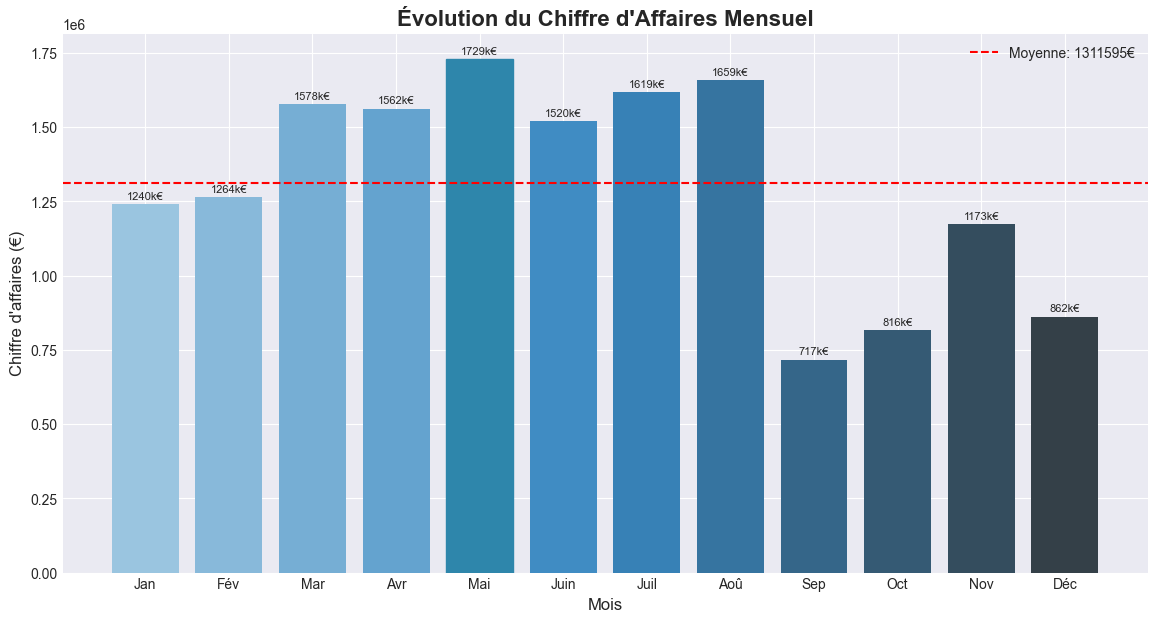

In [377]:
CA_Mensuel_plot = CA_Mensuel.sort_index()
plt.figure(figsize=(14, 7))
bars = plt.bar(CA_Mensuel_plot.index, CA_Mensuel_plot.values, color=sns.color_palette("Blues_d", 12))
max_idx = CA_Mensuel_plot.idxmax()
bars[max_idx-1].set_color('#2E86AB')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Chiffre d\'affaires (€)', fontsize=12)
plt.title('Évolution du Chiffre d\'Affaires Mensuel', fontsize=16, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])
plt.axhline(y=CA_Mensuel_plot.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne: {CA_Mensuel_plot.mean():.0f}€')
for i, v in enumerate(CA_Mensuel_plot.values):
    plt.text(i+1, v + 10000, f'{v/1000:.0f}k€', ha='center', va='bottom', fontsize=8, rotation=0)
plt.legend()

In [153]:
Nbre_commande = Ventes.Sequence_paiement.sum()
Nbre_produits = len(Ventes[(Ventes["Status_commande"]!='unavailable') & (Ventes["Status_commande"]!='canceled')])
Nbre_commande_Client = Ventes.groupby('customer_id')['Sequence_paiement'].sum()

print(f"•	Nombre total de commandes : {Nbre_commande}")
print(f"•	Nombre total de produits vendus : {Nbre_produits} avec {len(Ventes)-Nbre_produits} de produits non vendus")
print(f"•	Top 10 du nombre de commandes par clients \n{Nbre_commande_Client.sort_values(ascending=False).head(10)}")

•	Nombre total de commandes : 113514
•	Nombre total de produits vendus : 102573 avec 1313 de produits non vendus
•	Top 10 du nombre de commandes par clients 
customer_id
9af2372a1e49340278e7c1ef8d749f34    435
92cd3ec6e2d643d4ebd0e3d6238f69e2    351
b246eeed30b362c09d867b9e598bee51    253
270c23a11d024a44c896d1894b261a83    231
eed931d3a5222a9a511d18be7fd2a5ba    190
13aa59158da63ba0e93ec6ac2c07aacb    190
de832e8dbb1f588a47013e53feaa67cc    120
1eebfdb7083031b40f727fb71f6cd5b2    120
7bb57d182bdc11653fac1593436df8bf    105
d1ea705f2fdd8f98eff86c2691652e60    105
Name: Sequence_paiement, dtype: int64


In [154]:
Panier_moyen = Ventes.Montant_paiement[(Ventes["Status_commande"]!='unavailable') & (Ventes["Status_commande"]!='canceled')].mean()

print(f"•	Panier moyen: {round(Panier_moyen,2)} euros")

•	Panier moyen: 153.44 euros


In [155]:
Commande_non_livree = Ventes[(Ventes["Status_commande"]=='unavailable') | (Ventes["Status_commande"]=='canceled')].copy()
Commande_livree = Ventes[(Ventes["Status_commande"]!='unavailable') & (Ventes["Status_commande"]!='canceled')].copy()

Commande_non_livree.head()

,order_id,Echéancier_paiement,Type_paiement,Sequence_paiement,Montant_paiement,customer_id,Status_commande,Date_achat_commande,Date_approbation_commande,Date_livraison_transporteur,Date_livraison_estime,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre
15,54a8822ca8bfc9d79e1154a2e20221e0,1,boleto,1,349.57,b2bc30625c47b506516778f17725b728,canceled,2017-11-26,2017-11-28,1900-01-01,2017-12-14,11,26,2017,4
26,6cf51ab464bdd9f7b282f5fe72391383,1,credit_card,1,64.17,6b8d0ddc6f0be6c4895f69fae60edf2f,canceled,2018-02-27,2018-02-27,2018-02-28,2018-03-13,2,27,2018,1
43,a402af38a74c44926247db438245d95c,5,credit_card,1,282.25,3ba47b09546c2da91ef141efce2d5888,canceled,2018-01-30,2018-01-30,1900-01-01,2018-03-06,1,30,2018,1
114,0cb763300f5679bee73a0b0fdfe0a2d2,1,voucher,1,981.68,f3fb421cdedc2519a5d2f5c75f2cb843,canceled,2018-08-10,1900-01-01,1900-01-01,2018-09-04,8,10,2018,3
319,2f6492ebb2badd06db511b63ae7d7f55,2,credit_card,1,189.37,0ffc8e8c374a394b0715d65963d641f1,canceled,2018-01-20,2018-01-20,2018-01-22,2018-02-20,1,20,2018,1


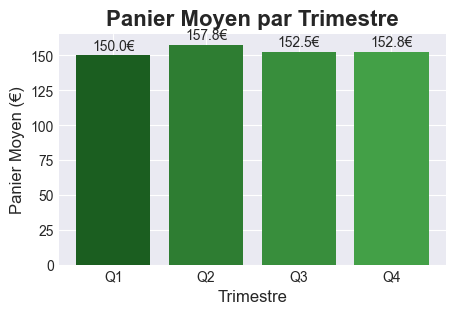

In [381]:
panier_trimestre = Commande_livree.groupby('Trimestre')['Montant_paiement'].mean()
plt.figure(figsize=(5, 3))
bars = plt.bar(panier_trimestre.index, panier_trimestre.values, 
               color=['#1B5E20', '#2E7D32', '#388E3C', '#43A047'])
plt.xlabel('Trimestre', fontsize=12)
plt.ylabel('Panier Moyen (€)', fontsize=12)
plt.title('Panier Moyen par Trimestre', fontsize=16, fontweight='bold')
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
for i, v in enumerate(panier_trimestre.values):
    plt.text(i+1, v + 2, f'{v:.1f}€', ha='center', va='bottom', fontsize=10)

Text(0.5, 1.0, 'Répartition des Types de Paiement')

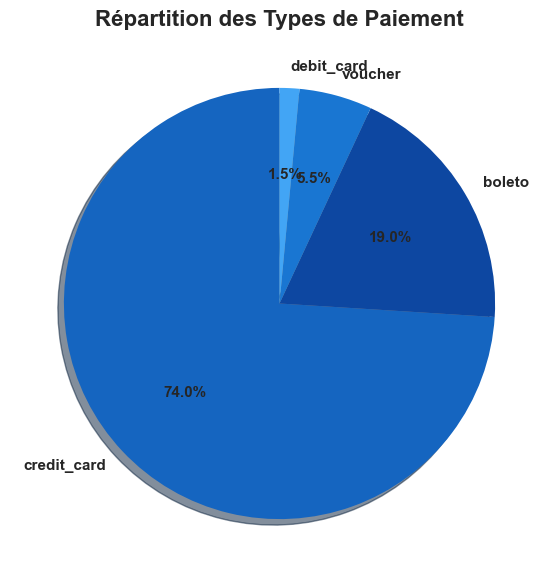

In [396]:
types_paiement = Commande_livree['Type_paiement'].value_counts()
plt.figure(figsize=(10, 7))
colors = ['#1565C0', '#0D47A1', '#1976D2', '#42A5F5']
plt.pie(types_paiement.values, labels=types_paiement.index, autopct='%1.1f%%',
        colors=colors, shadow=True, startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Répartition des Types de Paiement', fontsize=16, fontweight='bold')

In [237]:
commandes_annulees = len(Commande_non_livree[Commande_non_livree['Status_commande']=="canceled"])
commandes_stock_indispo = len(Commande_non_livree[Commande_non_livree['Status_commande']=="unavailable"])

print(f"{commandes_annulees} commandes ont été annulées...")
print(f"{commandes_stock_indispo} commandes ne sont pas pris en compte car les articles étaient indisponibles")

Type_paie_echeancier_Non = Commande_non_livree[Commande_non_livree['Status_commande']=="canceled"].groupby('Type_paiement').agg({
    'Echéancier_paiement' : ['sum'],
    'Sequence_paiement': ['count'],
    'Montant_paiement':['sum']
})
Type_paie_echeancier = Commande_livree.groupby('Type_paiement').agg({
    'Echéancier_paiement' : ['sum'],
    'Sequence_paiement': ['count'],
    'Montant_paiement':['sum']
})
print("Echéancier de paiement , sequence_paiement, Montant_paiement groupés par type de paiement : commandes annulées")
Type_paie_echeancier_Non.sort_values(by='Type_paiement', ascending=False)

664 commandes ont été annulées...
649 commandes ne sont pas pris en compte car les articles étaient indisponibles
Echéancier de paiement , sequence_paiement, Montant_paiement groupés par type de paiement : commandes annulées


,Echéancier_paiement,Sequence_paiement,Montant_paiement
,sum,count,sum
Type_paiement,,,
voucher,115,115,25664.92
not_defined,3,3,0.00
debit_card,7,7,2711.27
credit_card,1631,444,97375.31
boleto,95,95,17504.10


In [157]:
print("Echéancier de paiement , sequence_paiement, Montant_paiement groupés par type de paiement ")
Type_paie_echeancier.sort_values(by='Type_paiement', ascending=False)

Echéancier de paiement , sequence_paiement, Montant_paiement groupés par type de paiement 


,Echéancier_paiement,Sequence_paiement,Montant_paiement
,sum,count,sum
Type_paiement,,,
voucher,5613,5613,349874.40
debit_card,1516,1516,212417.75
credit_card,266118,75905,12350042.56
boleto,19539,19539,2826802.30


In [158]:
print(f"Affichons les échéancier de paiement des montants les plus élevés des commandes qui ont été annulées")
Commandes_non_livree_montant_eleve = Commande_non_livree[(Commande_non_livree['Status_commande'] == "canceled") & (Commande_non_livree['Type_paiement'] == 'credit_card')].groupby('Montant_paiement').agg({
    'Echéancier_paiement': ["sum"],
    'Sequence_paiement': ['count']})
Commandes_non_livree_montant_eleve.sort_values(by="Montant_paiement", ascending=False).head()

Affichons les échéancier de paiement des montants les plus élevés des commandes qui ont été annulées


,Echéancier_paiement,Sequence_paiement
,sum,count
Montant_paiement,,
4809.44,5,1
2442.82,2,1
2419.20,10,1
2404.72,10,1
2026.54,10,1


In [159]:
print(f"Affichons les échéancier de paiement des montants les plus élevés des commandes vendues")
Commandes_livree_montant_eleve = Commande_livree[(Commande_livree['Type_paiement'] == 'credit_card')].groupby('Montant_paiement').agg({
    'Echéancier_paiement': ["sum"],
    'Sequence_paiement': ['count']})
Commandes_livree_montant_eleve.sort_values(by="Montant_paiement", ascending=False).head()

Affichons les échéancier de paiement des montants les plus élevés des commandes vendues


,Echéancier_paiement,Sequence_paiement
,sum,count
Montant_paiement,,
13664.08,1,1
6929.31,8,1
4950.34,10,1
4764.34,8,1
4681.78,8,1


In [160]:
print("Voyons voir s'ils sont en retard sur leurs livraisons, c'est à dire que la date de livraison estimée communiquée au client lors du paiement est respectée")

Nbre_commande_livre_retard = len(Commande_non_livree[Commande_non_livree['Date_livraison_transporteur']>Commande_non_livree['Date_livraison_estime']])
Nbre_commande_livre_heure = len(Commande_non_livree[Commande_non_livree['Date_livraison_transporteur']<=Commande_non_livree['Date_livraison_estime']])

print(f"{Nbre_commande_livre_retard} commande(s) ont été livrés en retard sur {Nbre_commande_livre_heure} commandes qui ont été livré à l'heure mais on été supprimées ou retournées...")


Voyons voir s'ils sont en retard sur leurs livraisons, c'est à dire que la date de livraison estimée communiquée au client lors du paiement est respectée
0 commande(s) ont été livrés en retard sur 1313 commandes qui ont été livré à l'heure mais on été supprimées ou retournées...


In [161]:
Commandes_periode_jour_vendus = Commande_livree.groupby("Jour_ventes").agg({
    'Sequence_paiement': 'count',
    "Montant_paiement": 'sum'
})

print(f"•	Commandes par jour: \n{Commandes_periode_jour_vendus.sort_values(by="Montant_paiement", ascending=False).head()}")

•	Commandes par jour: 
             Sequence_paiement  Montant_paiement
Jour_ventes                                     
24                        3992         595654.95
16                        3721         569845.82
18                        3560         569174.15
4                         3578         565028.77
6                         3545         560726.52


In [162]:
Commandes_periode_mois_vendus = Commande_livree.groupby('Mois_ventes').agg({
    'Sequence_paiement': 'count',
    "Montant_paiement": 'sum'})

print(f"•	Commandes par mois: \n{Commandes_periode_mois_vendus.sort_values(by="Montant_paiement", ascending=False).head()}")

•	Commandes par mois: 
             Sequence_paiement  Montant_paiement
Mois_ventes                                     
5                        10971        1728674.79
8                        11079        1658967.92
7                        10670        1618738.74
3                        10239        1578393.14
4                         9732        1562292.29


In [163]:
Commandes_periode_trimestre_vendus = Commande_livree.groupby('Trimestre').agg({
    'Sequence_paiement': 'count',
    "Montant_paiement": 'sum'})

print(f"•	Commandes par trimestre: \n{Commandes_periode_trimestre_vendus.sort_values(by="Montant_paiement", ascending=False).head()}")

•	Commandes par trimestre: 
           Sequence_paiement  Montant_paiement
Trimestre                                     
2                      30493        4811288.84
1                      27219        4081627.48
3                      26201        3995204.57
4                      18660        2851016.12


In [164]:
panier_annule = Commande_non_livree['Montant_paiement'][Commande_non_livree.Status_commande == "canceled"].mean()
panier_livre = Commande_livree['Montant_paiement'].mean()
    
print(f"Le panier moyen des commandes annulées s'élève à : {round(panier_annule, 2)} euros")
print(f"Le panier moyen des commandes livrées s'élève à : {round(panier_livre, 2)} euros")

Le panier moyen des commandes annulées s'élève à : 215.75 euros
Le panier moyen des commandes livrées s'élève à : 153.44 euros


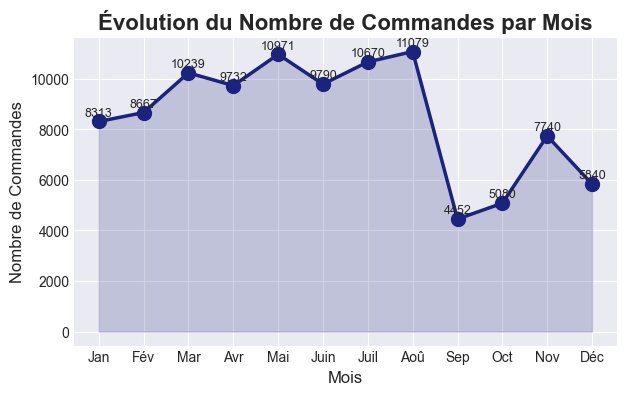

In [384]:
commandes_mois = Commande_livree.groupby('Mois_ventes')['Sequence_paiement'].count()
plt.figure(figsize=(7, 4))
plt.plot(commandes_mois.index, commandes_mois.values, marker='o', linestyle='-', linewidth=2.5, 
         markersize=10, color='#1A237E')
plt.fill_between(commandes_mois.index, commandes_mois.values, alpha=0.2, color='#1A237E')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Nombre de Commandes', fontsize=12)
plt.title('Évolution du Nombre de Commandes par Mois', fontsize=16, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])
for i, v in enumerate(commandes_mois.values):
    plt.text(i+1, v + 100, f'{v}', ha='center', va='bottom', fontsize=9)

### ***ANALYSE DES VENTES***

D'après les différents resultats, on peut émettre plusieurs hypothèses:

--- Sur le plan de la livraison : on peut dire que les dates sont toujours supérieures à celles de la livraison par le transporteur, donc en clair, ils sont ponctuels sur l'estimation, mais il reste encore à vérifier plutard s'ils le sont aussi sur l'expédition et si le délai re livraison n'est pas trop éloigné à la date d'achat...

--- On observe qu'il y a près de 664 commandes qui ont été annulées conte 649 commandes ne sont pas pris en compte car les articles étaient indisponibles,

    Pour les commandes dont les articles étaient non disponibles, l'explication plausible serait que le stock était insuffisant (l'offre a été supérieure à la demande).

    Pour les commandes annulées, là il n y a pas d'explication plausible d'après les analyses, mais on peut emettre des hypothèses:
        --- Le panier moyen des commandes annulées est plutot élevé que celui du panier moyen des commandes livrées, ce qui montrerait peut etre que :
            ---Le client a trouvé les articles trop chers par rapport peut etre à ailleurs où il a pu comparé (promotions et autres)...
            ---Les articles étaient trop chers pour leurs qualités, c'est à dire que le rapport qualité/prix n'était pas fameux
            ---Le client voulait juste faire une simulation...
            ---Le client s'est désisté, a changé d'avis sur l'achat des articles, et s'est dit qu'il va économiser son argent.

        --- Les dates de livraisons estimées sont toujours supérieures à celles de la livraison ce qui montre que les commandes ne sont pas annulées à cause d'un quelconque retard,

        --- On peut remarquer que la majeure partie des commandes annulées, articles indisponibles ou livrées sont payées par carte de crédit (bancaire), de plus les clients des commandes annulées ont spécialement les échéanciers de paiement plutot bas pour des montants similaires au commandes livrées et compatabilisées qui eux ont des échéanciers de paiement plutot éléves, ce qui nous mène à émettre plusieurs hypothèses:
            --- Une annulation des débits de la banque des mensualités selon l'échéancier de paiement (solde insuffisant),
            --- Un carte de crédit n'étant pas paramétrée pour les paiements en plusieurs fois (à vérifier via les logs d'erreurs), rejété donc pour respecter l'échéancier de paiement,
            --- Des échéanciers de paiement avec une courte période augmentent donc le montant à prélevé sur le compte du client, d'où la probabilité de tomber sur un compte qui a un solde inférieur à celui de l'échéancier est élevé, après une longue période sans régulariser,peux suivre les clauses pour résoudre des litiges selon les CGV, notamment une annulation de la commande ainsi que des rappels,... 


En ce qui concerne les gains de l'entreprise, les meilleurs ventes sont effectuées au 2ème trimestre avec un CA de 4,811,288.84 d'euros, plus précisement au mois de Mai avec un CA de 1,728,674.79 d'euros, pour etre encore plus précis c'est le 24 mai avec un CA de 595,654.95 euros la journée pendant laquelle l'entreprise a fait le gain le plus élevé par rapport aux autres jours de l'année.


### ***b.KPI CLIENTS***

In [165]:
pd.set_option("display.max_columns", None)

In [166]:
Clients_Vente = pd.merge(Clients, Ventes, on="order_id", how="left")

Clients_Vente.head()

,customer_id_x,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,Echéancier_paiement,Type_paiement,Sequence_paiement,Montant_paiement,customer_id_y,Status_commande,Date_achat_commande,Date_approbation_commande,Date_livraison_transporteur,Date_livraison_estime,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre
0,943fcdf63bb3f4757a902d8837c2dabd,f9bfd06239b3ed989017fc7d2ff82474,29194,aracruz,ES,417996696d91e1f74fe36c995ab65b97,delivered,2018-03-08,2018-03-08,2018-03-08,2018-03-29,3.0,credit_card,1.0,67.22,943fcdf63bb3f4757a902d8837c2dabd,delivered,2018-03-08,2018-03-08,2018-03-08,2018-03-29,3.0,8.0,2018.0,1.0
1,c1b3abc0f5a34a1b1bf279c0e3697621,0a2bfc7b9705c3e494be7c34a99cade9,93510,novo hamburgo,RS,531b7ebd1fe920da63f51af4667a7962,delivered,2018-08-02,2018-08-02,2018-08-03,2018-08-17,1.0,credit_card,1.0,345.38,c1b3abc0f5a34a1b1bf279c0e3697621,delivered,2018-08-02,2018-08-02,2018-08-03,2018-08-17,8.0,2.0,2018.0,3.0
2,3a79e64decb3ffe215a91a9fd8989abc,5dc058a598fa151b2ccd316b3ad78127,95060,caxias do sul,RS,5d3e1dc4bcf34ae3292fdd4dfb5c65a9,delivered,2017-10-28,2017-10-28,2017-10-30,2017-11-28,1.0,credit_card,1.0,28.00,3a79e64decb3ffe215a91a9fd8989abc,delivered,2017-10-28,2017-10-28,2017-10-30,2017-11-28,10.0,28.0,2017.0,4.0
3,345243f3e37e32114d9cf17eb7a11c29,8f7036a46f0fba0b1caea70c6ca36203,3254,sao paulo,SP,95d31d53ccc53bca2c13fcd535d67526,delivered,2016-10-07,2016-10-07,2016-10-15,2016-12-05,7.0,credit_card,1.0,192.55,345243f3e37e32114d9cf17eb7a11c29,delivered,2016-10-07,2016-10-07,2016-10-15,2016-12-05,10.0,7.0,2016.0,4.0
4,6f48e6b45dd4260e3067e65407358d65,07eb0cbb880bbc6f91711079f76bc95f,5864,sao paulo,SP,e471b8e7eaa8fd21277e359033828817,delivered,2017-12-04,2017-12-04,2017-12-07,2017-12-26,2.0,credit_card,1.0,149.73,6f48e6b45dd4260e3067e65407358d65,delivered,2017-12-04,2017-12-04,2017-12-07,2017-12-26,12.0,4.0,2017.0,4.0


In [167]:
Nbre_Clients = len(Clients_Vente)

Nbre_Clients_unique = Clients_Vente.customer_unique_id.nunique()

Nbre_Clients_recurrents = Nbre_Clients - Nbre_Clients_unique

Taux_fidelisation = (Nbre_Clients_recurrents/Nbre_Clients)*100

Date_actuelle_dataset = Clients_Vente["order_purchase_timestamp"].max()

print(f"•	Nombre total de clients : {Nbre_Clients} clients")
print(f"•	Nombre de clients uniques : {Nbre_Clients_unique} clients")
print(f"•	Nombre de clients récurrents : {Nbre_Clients_recurrents} clients")
print(f"•	Taux de fidélisation : {round(Taux_fidelisation, 2)}%")
print(f"•   La date la plus récente selon le dataset est : {Date_actuelle_dataset}")

•	Nombre total de clients : 103887 clients
•	Nombre de clients uniques : 96096 clients
•	Nombre de clients récurrents : 7791 clients
•	Taux de fidélisation : 7.5%
•   La date la plus récente selon le dataset est : 2018-10-17


In [168]:
def status_client(x):
    if pd.isna(x):
        return "Aucun status"    
    recency = pd.to_datetime(Date_actuelle_dataset) - pd.to_datetime(x)
    if recency <= pd.Timedelta(days=90):
        return "Actif"
    else:
        return "Inactif"

Clients_Vente['Status_Client'] = Clients_Vente["order_purchase_timestamp"].apply(status_client)

Clients_Vente.head()

,customer_id_x,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,Echéancier_paiement,Type_paiement,Sequence_paiement,Montant_paiement,customer_id_y,Status_commande,Date_achat_commande,Date_approbation_commande,Date_livraison_transporteur,Date_livraison_estime,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre,Status_Client
0,943fcdf63bb3f4757a902d8837c2dabd,f9bfd06239b3ed989017fc7d2ff82474,29194,aracruz,ES,417996696d91e1f74fe36c995ab65b97,delivered,2018-03-08,2018-03-08,2018-03-08,2018-03-29,3.0,credit_card,1.0,67.22,943fcdf63bb3f4757a902d8837c2dabd,delivered,2018-03-08,2018-03-08,2018-03-08,2018-03-29,3.0,8.0,2018.0,1.0,Inactif
1,c1b3abc0f5a34a1b1bf279c0e3697621,0a2bfc7b9705c3e494be7c34a99cade9,93510,novo hamburgo,RS,531b7ebd1fe920da63f51af4667a7962,delivered,2018-08-02,2018-08-02,2018-08-03,2018-08-17,1.0,credit_card,1.0,345.38,c1b3abc0f5a34a1b1bf279c0e3697621,delivered,2018-08-02,2018-08-02,2018-08-03,2018-08-17,8.0,2.0,2018.0,3.0,Actif
2,3a79e64decb3ffe215a91a9fd8989abc,5dc058a598fa151b2ccd316b3ad78127,95060,caxias do sul,RS,5d3e1dc4bcf34ae3292fdd4dfb5c65a9,delivered,2017-10-28,2017-10-28,2017-10-30,2017-11-28,1.0,credit_card,1.0,28.00,3a79e64decb3ffe215a91a9fd8989abc,delivered,2017-10-28,2017-10-28,2017-10-30,2017-11-28,10.0,28.0,2017.0,4.0,Inactif
3,345243f3e37e32114d9cf17eb7a11c29,8f7036a46f0fba0b1caea70c6ca36203,3254,sao paulo,SP,95d31d53ccc53bca2c13fcd535d67526,delivered,2016-10-07,2016-10-07,2016-10-15,2016-12-05,7.0,credit_card,1.0,192.55,345243f3e37e32114d9cf17eb7a11c29,delivered,2016-10-07,2016-10-07,2016-10-15,2016-12-05,10.0,7.0,2016.0,4.0,Inactif
4,6f48e6b45dd4260e3067e65407358d65,07eb0cbb880bbc6f91711079f76bc95f,5864,sao paulo,SP,e471b8e7eaa8fd21277e359033828817,delivered,2017-12-04,2017-12-04,2017-12-07,2017-12-26,2.0,credit_card,1.0,149.73,6f48e6b45dd4260e3067e65407358d65,delivered,2017-12-04,2017-12-04,2017-12-07,2017-12-26,12.0,4.0,2017.0,4.0,Inactif


In [169]:
Taux_churn = (len(Clients_Vente[Clients_Vente.Status_Client == "Inactif"])/len(Clients_Vente))*100

Freq_achat = Clients_Vente.groupby('customer_id_x')['order_id'].nunique()

Client_ville = Clients_Vente.groupby('customer_city')['customer_unique_id'].count()

Client_zip_code = Clients_Vente.groupby("customer_zip_code_prefix")["customer_unique_id"].count()

print(f"•	Taux de churn (clients inactifs) : {round(Taux_churn,2)} %") 
print(f"•	Fréquence d’achat moyenne par client : {Freq_achat.mean()}")
print(f"•	Clients par ville : \n{Client_ville.sort_values(ascending=False).head()}\n")
print(f"•   Clients par zip_code: \n{Client_zip_code.sort_values(ascending=False).head()}")

•	Taux de churn (clients inactifs) : 90.39 %
•	Fréquence d’achat moyenne par client : 1.0
•	Clients par ville : 
customer_city
sao paulo         16221
rio de janeiro     7207
belo horizonte     2872
brasilia           2193
curitiba           1576
Name: customer_unique_id, dtype: int64

•   Clients par zip_code: 
customer_zip_code_prefix
22790    143
24220    137
22793    123
24230    121
22775    114
Name: customer_unique_id, dtype: int64


In [399]:
Clients_Vente["Churn"] = Clients_Vente["Status_Client"].apply(lambda x: 0 if x == "Inactif" else 1)

In [402]:
Clients_Vente.head(2)

,customer_id_x,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,Echéancier_paiement,Type_paiement,Sequence_paiement,Montant_paiement,customer_id_y,Status_commande,Date_achat_commande,Date_approbation_commande,Date_livraison_transporteur,Date_livraison_estime,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre,Status_Client,Churn
0,943fcdf63bb3f4757a902d8837c2dabd,f9bfd06239b3ed989017fc7d2ff82474,29194,aracruz,ES,417996696d91e1f74fe36c995ab65b97,delivered,2018-03-08,2018-03-08,2018-03-08,2018-03-29,3.0,credit_card,1.0,67.22,943fcdf63bb3f4757a902d8837c2dabd,delivered,2018-03-08,2018-03-08,2018-03-08,2018-03-29,3.0,8.0,2018.0,1.0,Inactif,0
1,c1b3abc0f5a34a1b1bf279c0e3697621,0a2bfc7b9705c3e494be7c34a99cade9,93510,novo hamburgo,RS,531b7ebd1fe920da63f51af4667a7962,delivered,2018-08-02,2018-08-02,2018-08-03,2018-08-17,1.0,credit_card,1.0,345.38,c1b3abc0f5a34a1b1bf279c0e3697621,delivered,2018-08-02,2018-08-02,2018-08-03,2018-08-17,8.0,2.0,2018.0,3.0,Actif,1


In [403]:
Clients_Vente.select_dtypes(include=['int', 'float']).corr()

,customer_zip_code_prefix,Echéancier_paiement,Sequence_paiement,Montant_paiement,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre,Churn
customer_zip_code_prefix,1.000000,0.055552,-0.017789,0.058128,-0.005924,-0.008079,-0.033061,-0.005136,-0.036359
Echéancier_paiement,0.055552,1.000000,-0.086363,0.330811,0.029635,0.001416,-0.052522,0.026496,-0.019259
Sequence_paiement,-0.017789,-0.086363,1.000000,-0.069593,-0.000364,-0.006413,-0.045272,-0.001146,-0.023300
Montant_paiement,0.058128,0.330811,-0.069593,1.000000,0.002748,-0.008391,0.005411,0.003093,0.002667
Mois_ventes,-0.005924,0.029635,-0.000364,0.002748,1.000000,0.002678,-0.547980,0.969800,0.165880
Jour_ventes,-0.008079,0.001416,-0.006413,-0.008391,0.002678,1.000000,-0.043400,0.017420,0.027436
Annee_Vente,-0.033061,-0.052522,-0.045272,0.005411,-0.547980,-0.043400,1.000000,-0.525700,0.299431
Trimestre,-0.005136,0.026496,-0.001146,0.003093,0.969800,0.017420,-0.525700,1.000000,0.198156
Churn,-0.036359,-0.019259,-0.023300,0.002667,0.165880,0.027436,0.299431,0.198156,1.000000


Prédiction du churn (on prédit si un client sera inactif ou pas...)
Précision du modèle : 90.49 %


C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


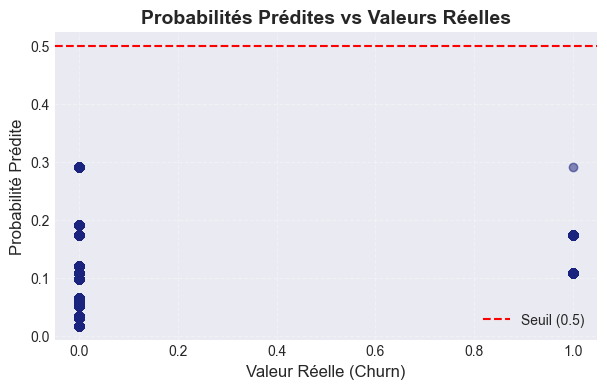

In [ ]:
print("Prédiction du churn (on prédit si un client sera inactif ou pas...)")

Clients_Vente["Mois_ventes"] = Clients_Vente["Mois_ventes"].fillna(Clients_Vente["Mois_ventes"].mean())
Clients_Vente["Annee_Vente"] = Clients_Vente["Annee_Vente"].fillna(Clients_Vente["Annee_Vente"].mean())
Clients_Vente["Trimestre"] = Clients_Vente["Trimestre"].fillna(Clients_Vente["Trimestre"].mean())

x = Clients_Vente[["Mois_ventes", "Annee_Vente", "Trimestre"]]
y = Clients_Vente["Churn"]

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, train_size=0.8)

model = LogisticRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_pred_proba = model.predict_proba(x_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle : {accuracy * 100:.2f} %")

plt.figure(figsize=(7, 4))
plt.scatter(y_test, y_pred_proba , alpha=0.3, color='#1A237E')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Seuil (0.5)')
plt.xlabel('Valeur Réelle (Churn)', fontsize=12)
plt.ylabel('Probabilité Prédite', fontsize=12)
plt.title('Probabilités Prédites vs Valeurs Réelles', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)


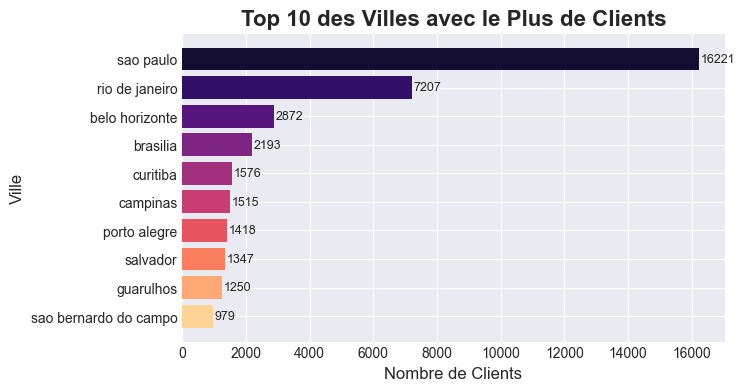

In [388]:
top_villes = Clients_Vente['customer_city'].value_counts().head(10)
plt.figure(figsize=(7, 4))
bars = plt.barh(top_villes.index, top_villes.values, color=sns.color_palette("magma", 10))
plt.xlabel('Nombre de Clients', fontsize=12)
plt.ylabel('Ville', fontsize=12)
plt.title('Top 10 des Villes avec le Plus de Clients', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_villes.values):
    plt.text(v + 50, i, f'{v}', va='center', fontsize=9)

### ***ANALYSE DES CLIENTS***

Au vue de notre précedénte analyse, nous pouvons constater qu'il y a une faible fidélisation des clients qui est de 7.5% avec un taux de clients inactifs s'élevant à 90.39%, ce qui revèle pour la suite qu'on peut avoir une mauvaise satisfaction des clients (mauvais retour de la part des clients).

De plus, la majorité des clients se trouvent dans la ville de SAO PAULO plus précisement dans la commune avec un code postal 22790...

### ***C.KPI SATISFACTION CLIENT***

In [170]:
# Renommage des colonnes
Satisfaction.rename(columns={
    '"order_id"': "order_id",
    '"order_status"': "order_status",
    '"order_purchase_timestamp"': "order_purchase_timestamp",	
    '"order_approved_at"': "order_approved_at",
    '"order_delivered_carrier_date"': "order_delivered_carrier_date",
    '"order_estimated_delivery_date"': "order_estimated_delivery_date"
}, inplace=True)

In [171]:
Satisfaction.head()

,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date
0,7bc2406110b926393aa56f80a40eba40,4.0,NaN,NaN,18/01/2018,18/01/2018,NaN,NaN,NaN,NaN,NaN,NaN
1,80e641a11e56f04c1ad469d5645fdfde,5.0,NaN,NaN,10/03/2018,11/03/2018,a548910a1c6147796b98fdf73dbeba33,delivered,28/02/2018,28/02/2018,02/03/2018,14/03/2018
2,228ce5500dc1d8e020d8d1322874b6f0,5.0,NaN,NaN,17/02/2018,18/02/2018,f9e4b658b201a9f2ecdecbb34bed034b,delivered,03/02/2018,03/02/2018,06/02/2018,09/03/2018
3,e64fb393e7b32834bb789ff8bb30750e,5.0,NaN,Recebi bem antes do prazo estipulado.,21/04/2017,21/04/2017,NaN,NaN,NaN,NaN,NaN,NaN
4,f7c4243c7fe1938f181bec41a392bdeb,5.0,NaN,Parabéns lojas lannister adorei comprar pela I...,01/03/2018,02/03/2018,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ANALYSE DES SENTIMENTS DES COMMENTAIRES DES CLIENTS 
# Reflexion: Un client peut mettre 5 ou 4 étoiles mais met un commentaire négatif et inversement, 
# 
# ce qui pourr
# ais fausser les calculs si on en prend pas compte...

sentiment = pipeline("sentiment-analysis")

def Analyse_Sentiment(x):
    if pd.isna(x):
        return None
    return sentiment(x)[0]['label']

Satisfaction['Analyse_avis'] = Satisfaction['review_comment_message'].apply(Analyse_Sentiment)
Satisfaction.head(2)

In [173]:
Satisfaction = pd.merge(Satisfaction, Clients_Vente, on="order_id", how='left')

In [174]:
Note_moyenne = Satisfaction.review_score.mean()

Distribution_notes = Satisfaction.review_score.value_counts()

Pourcent_avis_positifs = (len(Satisfaction[(Satisfaction.review_score==4.0) | (Satisfaction.review_score==5.0) & (Satisfaction.review_score.isna()==False)])/len(Satisfaction))*100

Pourcent_avis_negatifs = (len(Satisfaction[(Satisfaction.review_score==1.0) | (Satisfaction.review_score==2.0) & (Satisfaction.review_score.isna()==False)])/len(Satisfaction))*100

print(f"•	Note moyenne des avis : {int(Note_moyenne)}")
print(f"•	Distribution des notes (1★ à 5★) : {Distribution_notes}")
print(f"•	% d’avis positifs (4★ et 5★) : {round(Pourcent_avis_positifs,2)}%")
print(f"•	% d’avis négatifs (1★ et 2★) : {round(Pourcent_avis_negatifs,2)}%")
print(f"•	Nombre total d’avis : {len(Satisfaction[Satisfaction.review_score.isna()==False])}")

•	Note moyenne des avis : 4
•	Distribution des notes (1★ à 5★) : review_score
5.0    57963
4.0    19295
1.0    11530
3.0     8270
2.0     3190
Name: count, dtype: int64
•	% d’avis positifs (4★ et 5★) : 77.07%
•	% d’avis négatifs (1★ et 2★) : 14.68%
•	Nombre total d’avis : 100248


Text(0, 0, '4.09\nMoyenne')

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


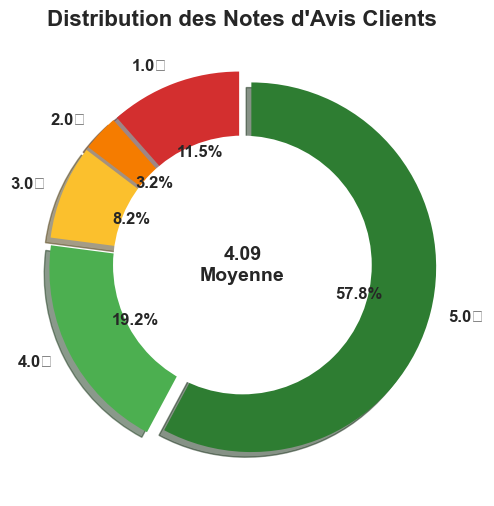

In [378]:
notes_data = Satisfaction.review_score.dropna()
plt.figure(figsize=(10, 6))
colors = ['#D32F2F', '#F57C00', '#FBC02D', '#4CAF50', '#2E7D32']
counts = notes_data.value_counts().sort_index()
explode = (0.05, 0.05, 0.05, 0.05, 0.05)
plt.pie(counts.values, labels=[f'{i}★' for i in counts.index], autopct='%1.1f%%', 
        colors=colors, explode=explode, shadow=True, startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Distribution des Notes d\'Avis Clients', fontsize=16, fontweight='bold')
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.text(0, 0, f'{notes_data.mean():.2f}\nMoyenne', ha='center', va='center', fontsize=14, fontweight='bold')

In [175]:
Satisfaction.head()

,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_id,order_status_x,order_purchase_timestamp_x,order_approved_at_x,order_delivered_carrier_date_x,order_estimated_delivery_date_x,customer_id_x,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status_y,order_purchase_timestamp_y,order_approved_at_y,order_delivered_carrier_date_y,order_estimated_delivery_date_y,Echéancier_paiement,Type_paiement,Sequence_paiement,Montant_paiement,customer_id_y,Status_commande,Date_achat_commande,Date_approbation_commande,Date_livraison_transporteur,Date_livraison_estime,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre,Status_Client
0,7bc2406110b926393aa56f80a40eba40,4.0,NaN,NaN,18/01/2018,18/01/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80e641a11e56f04c1ad469d5645fdfde,5.0,NaN,NaN,10/03/2018,11/03/2018,a548910a1c6147796b98fdf73dbeba33,delivered,28/02/2018,28/02/2018,02/03/2018,14/03/2018,8a2e7ef9053dea531e4dc76bd6d853e6,64190b91b656ab8f37eb89b93dc84584,13380.0,nova odessa,SP,delivered,2018-02-28,2018-02-28,2018-03-02,2018-03-14,1.0,credit_card,1.0,88.09,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28,2018-02-28,2018-03-02,2018-03-14,2.0,28.0,2018.0,1.0,Inactif
2,228ce5500dc1d8e020d8d1322874b6f0,5.0,NaN,NaN,17/02/2018,18/02/2018,f9e4b658b201a9f2ecdecbb34bed034b,delivered,03/02/2018,03/02/2018,06/02/2018,09/03/2018,e226dfed6544df5b7b87a48208690feb,1d47144362c14e94ccdd213e8ec277d5,44571.0,santo antonio de jesus,BA,delivered,2018-02-03,2018-02-03,2018-02-06,2018-03-09,1.0,credit_card,1.0,194.12,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03,2018-02-03,2018-02-06,2018-03-09,2.0,3.0,2018.0,1.0,Inactif
3,e64fb393e7b32834bb789ff8bb30750e,5.0,NaN,Recebi bem antes do prazo estipulado.,21/04/2017,21/04/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f7c4243c7fe1938f181bec41a392bdeb,5.0,NaN,Parabéns lojas lannister adorei comprar pela I...,01/03/2018,02/03/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [176]:
Satisfaction['Date_livraison_transporteur'] = pd.to_datetime(Satisfaction['Date_livraison_transporteur'][Satisfaction['Date_livraison_transporteur'] != 'NaN'])
Satisfaction['Date_achat_commande'] = pd.to_datetime(Satisfaction['Date_achat_commande'][Satisfaction['Date_achat_commande'] != 'NaN'])

Satisfaction['Délai_livraison'] = Satisfaction['Date_livraison_transporteur'] - Satisfaction['Date_achat_commande']
Delai_moyen_groupe = Satisfaction.groupby('review_score')['Délai_livraison'].mean()


print(f"•	Délai moyen vs note (impact livraison → satisfaction) : {Delai_moyen_groupe.sort_values(ascending=False)}")

•	Délai moyen vs note (impact livraison → satisfaction) : review_score
5.0     -94 days +07:50:28.234361932
4.0    -115 days +15:13:03.335609890
3.0    -459 days +02:41:55.023041472
2.0   -2125 days +08:55:45.682888544
1.0   -4841 days +08:30:41.184387584
Name: Délai_livraison, dtype: timedelta64[ns]


In [177]:
Livraison_zone_note = Satisfaction.groupby(['customer_city', 'customer_zip_code_prefix']).agg({
    'Délai_livraison':'mean','review_score': 'count'	
})

print(f"Délai de livraison par zone et note \n {Livraison_zone_note.sort_values(by="Délai_livraison", ascending=False)}")


Délai de livraison par zone et note 
                                         Délai_livraison  review_score
customer_city  customer_zip_code_prefix                              
curaca         48930.0                          48 days             1
boa vista      69304.0                          43 days             1
porteirinha    39520.0                          40 days             1
belo horizonte 30518.0                          39 days             1
recife         52190.0                          34 days             1
...                                                 ...           ...
sao paulo      2073.0                       -43310 days             1
               5505.0                       -43310 days             1
               3143.0                       -43316 days             1
               1242.0                       -43326 days             1
santa luzia    33030.0                      -43361 days             1

[11450 rows x 2 columns]


### ***ANALYSES SATISFACTION CLIENT***

Le client n'est clairement pas satisfait lorsque sa commande prend plus de temps à etre livrée. Cela est observable au niveau des notes où l'on attribue une note plus basse lorsque la date de livraison est plus éloignée meme si celle estimée est supérieure à celle ci (Les clients souhaitent recevoir le plus rapidement possible leur commande)...

On pourra dire que dans la majeure partie des cas, le client est satisfait vu que les avis positifs sont supérieurs à ceux négatifs ici.

Pour etre plus précis dans les zones où les délais sont les plus élevés (ville et code postal) et les mauvais avis qui vont avec sont:

curaca         48930.0                          48 days             
boa vista      69304.0                          43 days             
porteirinha    39520.0                          40 days             
belo horizonte 30518.0                          39 days             
recife         52190.0                          34 days             

Pour améliorer cette logistique, il faudra donc ouvrir différents dépots ou zones de distribution dans ces zones pour diminuer au maximum le délai de livraison...


### ***d.KPI PRODUITS***

In [178]:
Produits.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19,58.90,13.29,cool_stuff,58,598,4,28,9,14,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03,239.90,19.93,pet_shop,56,239,2,50,30,40,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18,199.00,17.87,moveis_decoracao,59,695,2,33,13,33,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15,12.99,12.79,perfumaria,42,480,1,16,10,15,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13,199.90,18.14,ferramentas_jardim,59,409,1,35,40,30,garden_tools


In [ ]:
Produits_vendus_categorie = Produits.groupby('product_category_name')['product_id'].count()
Produits['PrixXQty'] = Produits['price']*Produits['product_photos_qty']
Revenus_produits = Produits.groupby('product_category_name')["PrixXQty"].sum()

print(f"•	Nombre de produits vendus par catégorie : \n{Produits_vendus_categorie.sort_values(ascending=False)}")
print(f"•	Catégorie de produits les plus vendus (top 10) : \n{Produits_vendus_categorie.sort_values(ascending=False).head(10)}")
print(f"•	Catégorie de produits les moins vendus : \n{Produits_vendus_categorie.sort_values(ascending=True).head(10)}")
print(f"•	Revenus par categorie de produits: \n{Revenus_produits.sort_values(ascending=False).head(10)}")

•	Nombre de produits vendus par catégorie : 
product_category_name
cama_mesa_banho                  12718
beleza_saude                      9670
esporte_lazer                     8641
moveis_decoracao                  8334
informatica_acessorios            7827
                                 ...  
cds_dvds_musicais                   14
la_cuisine                          14
pc_gamer                             9
fashion_roupa_infanto_juvenil        8
seguros_e_servicos                   2
Name: product_id, Length: 73, dtype: int64
•	Catégorie de produits les plus vendus (top 10) : 
product_category_name
cama_mesa_banho           12718
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: product_id, dtype: int64
•	Catégorie de produits les moins ve

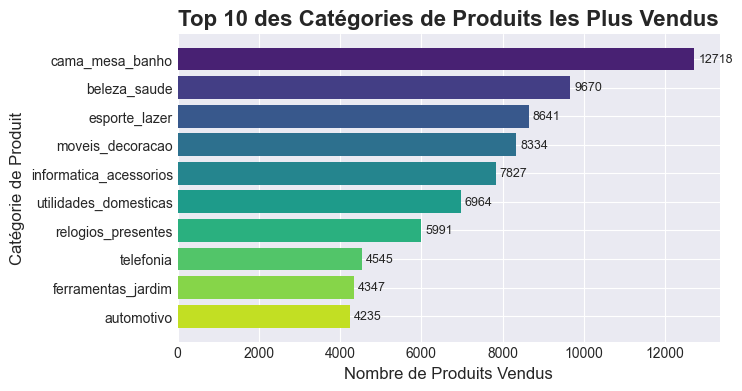

In [382]:
top_categories = Produits_vendus_categorie.sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 4))
bars = plt.barh(top_categories.index, top_categories.values, color=sns.color_palette("viridis", 10))
plt.xlabel('Nombre de Produits Vendus', fontsize=12)
plt.ylabel('Catégorie de Produit', fontsize=12)
plt.title('Top 10 des Catégories de Produits les Plus Vendus', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_categories.values):
    plt.text(v + 100, i, f'{v}', va='center', fontsize=9)

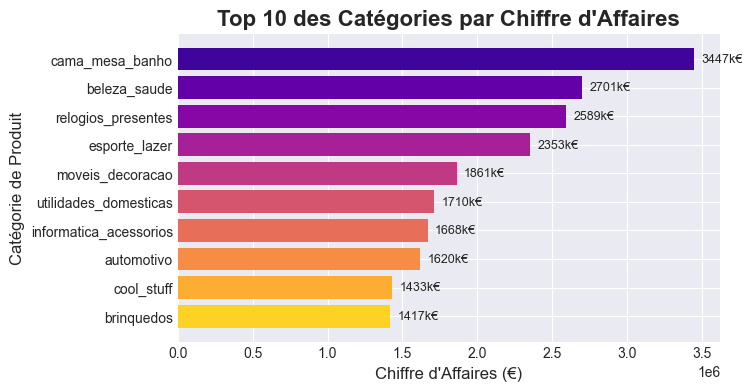

In [387]:
top_revenus = Revenus_produits.sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 4))
bars = plt.barh(top_revenus.index, top_revenus.values, color=sns.color_palette("plasma", 10))
plt.xlabel('Chiffre d\'Affaires (€)', fontsize=12)
plt.ylabel('Catégorie de Produit', fontsize=12)
plt.title('Top 10 des Catégories par Chiffre d\'Affaires', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_revenus.values):
    plt.text(v + 50000, i, f'{v/1000:.0f}k€', va='center', fontsize=9)

In [180]:
Produits = pd.merge(Produits, Satisfaction, on="order_id", how='left')
Produits.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,PrixXQty,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_status_x,order_purchase_timestamp_x,order_approved_at_x,order_delivered_carrier_date_x,order_estimated_delivery_date_x,customer_id_x,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status_y,order_purchase_timestamp_y,order_approved_at_y,order_delivered_carrier_date_y,order_estimated_delivery_date_y,Echéancier_paiement,Type_paiement,Sequence_paiement,Montant_paiement,customer_id_y,Status_commande,Date_achat_commande,Date_approbation_commande,Date_livraison_transporteur,Date_livraison_estime,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre,Status_Client,Délai_livraison
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19,58.90,13.29,cool_stuff,58,598,4,28,9,14,cool_stuff,235.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03,239.90,19.93,pet_shop,56,239,2,50,30,40,pet_shop,479.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18,199.00,17.87,moveis_decoracao,59,695,2,33,13,33,furniture_decor,398.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15,12.99,12.79,perfumaria,42,480,1,16,10,15,perfumery,12.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13,199.90,18.14,ferramentas_jardim,59,409,1,35,40,30,garden_tools,199.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [181]:
Categorie_mieux_note = Produits[(Produits.review_score == 4.0)|(Produits.review_score == 5.0)].groupby('product_category_name')['review_score'].max()
Categorie_moins_note = Produits[(Produits.review_score == 1.0)|(Produits.review_score == 2.0)].groupby('product_category_name')['review_score'].max()

print(f"•	Catégorie de produits les mieux notés : \n{Categorie_mieux_note.sort_values(ascending=False).head(10)}")
print(f"•	Produits les moins bien notés : \n{Categorie_moins_note.sort_values(ascending=True).head(10)}")

•	Catégorie de produits les mieux notés : 
product_category_name
agro_industria_e_comercio    5.0
alimentos                    5.0
moveis_colchao_e_estofado    5.0
market_place                 5.0
malas_acessorios             5.0
livros_tecnicos              5.0
livros_interesse_geral       5.0
livros_importados            5.0
la_cuisine                   5.0
instrumentos_musicais        5.0
Name: review_score, dtype: float64
•	Produits les moins bien notés : 
product_category_name
fashion_esporte                       1.0
dvds_blu_ray                          1.0
flores                                1.0
musica                                1.0
casa_conforto_2                       1.0
pc_gamer                              1.0
construcao_ferramentas_ferramentas    1.0
portateis_casa_forno_e_cafe           1.0
construcao_ferramentas_seguranca      1.0
seguros_e_servicos                    1.0
Name: review_score, dtype: float64


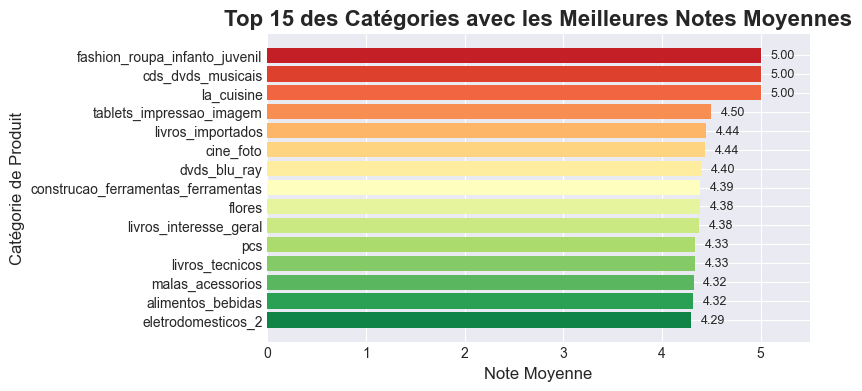

In [391]:
note_par_categorie = Produits.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(7, 4))
bars = plt.barh(note_par_categorie.index, note_par_categorie.values, 
                color=[sns.color_palette("RdYlGn", 15)[i] for i in range(15)])
plt.xlabel('Note Moyenne', fontsize=12)
plt.ylabel('Catégorie de Produit', fontsize=12)
plt.title('Top 15 des Catégories avec les Meilleures Notes Moyennes', fontsize=16, fontweight='bold')
plt.xlim(0, 5.5)
plt.gca().invert_yaxis()
for i, v in enumerate(note_par_categorie.values):
    plt.text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)

In [182]:
print(f"Expédition moyenne: {Produits.freight_value.mean()}")

Expédition moyenne: 19.99580512650555


In [183]:
Produits['shipping_limit_date'] = pd.to_datetime(Produits['shipping_limit_date'])

Produits['Délai_achat_expedition'] = Produits['Date_achat_commande'] - Produits['shipping_limit_date']

Frais_trans = Produits[(Produits.review_score == 1.0)|(Produits.review_score == 2.0)].groupby(['product_category_name','customer_city','customer_zip_code_prefix']).agg({
    'freight_value': 'max',
    'Délai_achat_expedition': 'max',
    'Délai_livraison':'max',
    'product_name_lenght': 'max',
    'product_description_lenght': 'max',
    'product_length_cm': 'max',
    'product_height_cm': 'max',
    'product_width_cm': 'max'
})

print(f"•	Transport sur les catégories de produits les moins bien notées + délai de livraison+dimensions : ")
Frais_trans.sort_values(by='Délai_livraison', ascending=False).head(15)

•	Transport sur les catégories de produits les moins bien notées + délai de livraison+dimensions : 


freight_value  \
product_category_name             customer_city     customer_zip_code_prefix                  
automotivo                        canaa dos carajas 68537.0                          108.96   
bebes                             patos de minas    38700.0                          140.91   
moveis_decoracao                  brasilia          71503.0                           20.74   
construcao_ferramentas_construcao rio de janeiro    20520.0                           20.42   
informatica_acessorios            curaca            48930.0                           26.53   
beleza_saude                      boa vista         69304.0                           28.24   
cama_mesa_banho                   sao paulo         8150.0                            25.96   
                                                    4216.0                            17.81   
                                                    1453.0                            17.81   
                                  passo fundo       99010.0                           32.71   
automotivo                        sao paulo         1309.0                            14.52   
cama_mesa_banho                   cangucu           96600.0                           21.47   
moveis_escritorio                 rio de janeiro    22440.0                           22.88   
cama_mesa_banho                   belo horizonte    30518.0                           23.80   
automotivo                        belo horizonte    30662.0                           41.43   

                                                                             Délai_achat_expedition  \
product_category_name             customer_city     customer_zip_code_prefix                          
automotivo                        canaa dos carajas 68537.0                                -21 days   
bebes                             patos de minas    38700.0                                -51 days   
moveis_decoracao                  brasilia          71503.0                                 -4 days   
construcao_ferramentas_construcao rio de janeiro    20520.0                                 -6 days   
informatica_acessorios            curaca            48930.0                                 -7 days   
beleza_saude                      boa vista         69304.0                                -25 days   
cama_mesa_banho                   sao paulo         8150.0                                  -6 days   
                                                    4216.0                                  -6 days   
                                                    1453.0                                  -6 days   
                                  passo fundo       99010.0                                 -6 days   
automotivo                        sao paulo         1309.0                                 -15 days   
cama_mesa_banho                   cangucu           96600.0                                 -5 days   
moveis_escritorio                 rio de janeiro    22440.0                                -35 days   
cama_mesa_banho                   belo horizonte    30518.0                                 -4 days   
automotivo                        belo horizonte    30662.0                                -15 days   

                                                                             Délai_livraison  \
product_category_name             customer_city     customer_zip_code_prefix                   
automotivo                        canaa dos carajas 68537.0                          61 days   
bebes                             patos de minas    38700.0                          50 days   
moveis_decoracao                  brasilia          71503.0                          50 days   
construcao_ferramentas_construcao rio de janeiro    20520.0                          49 days   
informatica_acessorios            curaca            48930.0                          48 days   
beleza_saude                      boa 

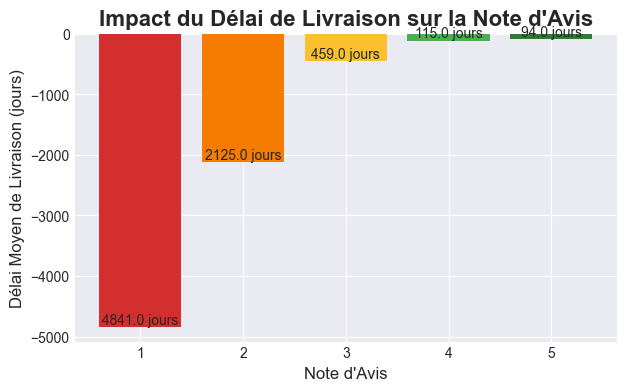

In [386]:
delai_moyen_par_note = Satisfaction.groupby('review_score')['Délai_livraison'].mean().dt.days
plt.figure(figsize=(7, 4))
bars = plt.bar(delai_moyen_par_note.index, delai_moyen_par_note.values,
               color=['#D32F2F', '#F57C00', '#FBC02D', '#4CAF50', '#2E7D32'])
plt.xlabel('Note d\'Avis', fontsize=12)
plt.ylabel('Délai Moyen de Livraison (jours)', fontsize=12)
plt.title('Impact du Délai de Livraison sur la Note d\'Avis', fontsize=16, fontweight='bold')
for i, v in enumerate(delai_moyen_par_note.values):
    plt.text(i+1, v + 2, f'{abs(v):.1f} jours', ha='center', va='bottom', fontsize=10)

### ***ANALYSES DES PRODUITS***

On peut observer une categorie de produits le plus vendu qui est cama_mesa_banho avec un CA plutot pas mal, mais il y en a aussi le moins vendu (seguros_e_servicos ,...) et ceux-ci sont évidemment moins bien notés vu qu'ils sont moins vendu (possibilité de mauvaise qualité à haut prix), il est donc question de comprendre le pourquoi?...

D'après les analyses, on contate que non seulement les frais d'expéditions sont élevés, cela voudrait dire que c'est une zone reculée ou l'état de la route est mauvaise, et en plus le colis est expédié en 21 jours et recu en 61 jours après l'achat soit plus d'un mois..., c'est le cas automotivo	dans la ville de canaa dos carajas ayant un code postal:68537.0; 

Résumé, niveau logistique, ce n'est pas au top, à noté que ce cas que j'ai décris plus haut est fréquent d'après les analyses...

Il serait nécessaire pour y remédier de positionner un point de distribution dans ces différentes zones ou à défaut, faire une regression linéaire sur les différentes zones pour déterminer la distance la plus petite entre toute les zones, histoire de maximiser le temps de livraisons et services (Voir la suite...)

### ***e.KPI MARKETING***

In [184]:
Marketing.rename(columns={
    "won_date": "Date de gain" , 
    "business_segment": "segment d'activité", 
    "lead_type":"type de prospect", 
    "lead_behaviour_profile" : "profil comportemental du prospect", 
    "has_company": "présence d'une entreprise", 
    "has_gtin": "présence d'un GTIN", 
    "average_stock": "stock moyen", 
    "business_type": "type d'entreprise", 
    "declared_product_catalog_size": "taille du catalogue produits déclarée", 
    "declared_monthly_revenue": "chiffre d'affaires mensuel déclaré", 
    "first_contact_date" : "date du premier contact", 
    "landing_page_id" : "identifiant de la page de destination", 
    "origin" : "origine"
}, inplace=True)

Marketing = pd.merge(Marketing, Produits, on="seller_id", how="left")
Marketing.head()

,mql_id,seller_id,sdr_id,sr_id,Date de gain,segment d'activité,type de prospect,profil comportemental du prospect,présence d'une entreprise,présence d'un GTIN,stock moyen,type d'entreprise,taille du catalogue produits déclarée,chiffre d'affaires mensuel déclaré,date du premier contact,identifiant de la page de destination,origine,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,PrixXQty,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_status_x,order_purchase_timestamp_x,order_approved_at_x,order_delivered_carrier_date_x,order_estimated_delivery_date_x,customer_id_x,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status_y,order_purchase_timestamp_y,order_approved_at_y,order_delivered_carrier_date_y,order_estimated_delivery_date_y,Echéancier_paiement,Type_paiement,Sequence_paiement,Montant_paiement,customer_id_y,Status_commande,Date_achat_commande,Date_approbation_commande,Date_livraison_transporteur,Date_livraison_estime,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre,Status_Client,Délai_livraison,Délai_achat_expedition
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26,pet,online_medium,cat,NaN,NaN,35,reseller,100.0,0.0,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,1efcc6ba75b519535a510c53153a9256,1.0,e94df75b2e9a8b056be0c144a731f55c,2018-06-26,94.2,18.76,pet_shop,56.0,1538.0,2.0,23.0,17.0,19.0,pet_shop,188.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
1,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26,pet,online_medium,cat,NaN,NaN,35,reseller,100.0,0.0,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,d8d281c1a1398a1e835fdc4adfb81e2a,1.0,9e0873e9ac04b12f282b81af5daebd2e,2018-07-30,664.0,38.41,ferramentas_jardim,25.0,432.0,1.0,29.0,29.0,29.0,garden_tools,664.0,5937d81cf570dcd7fd4fe8f5c9c293bc,1.0,Serviço de baixa qualidad,Recebi o produto errado. Comprei um Soprador ...,28/07/2018,28/07/2018,delivered,23/07/2018,24/07/2018,25/07/2018,07/08/2018,14c1e4101ca2dc7dbf876d9c9e6b11a6,7eb01c1ef439cd15ed3a4cc601d15dd8,14020.0,ribeirao preto,SP,delivered,2018-07-23,2018-07-24,2018-07-25,2018-08-07,7.0,credit_card,1.0,702.41,14c1e4101ca2dc7dbf876d9c9e6b11a6,delivered,2018-07-23,2018-07-24,2018-07-25,2018-08-07,7.0,23.0,2018.0,3.0,Actif,2 days,-7 days
2,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26,pet,online_medium,cat,NaN,NaN,35,reseller,100.0,0.0,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,e5858127da61f07285827883e605254b,1.0,9bb2d066e4b33b624cbdfec7d50b3dcb,2018-06-27,99.8,15.00,pet_shop,53.0,1494.0,2.0,26.0,19.0,23.0,pet_shop,199.6,b8e55f84a8b1dbfd424e7d03e743f0f5,5.0,NaN,NaN,26/06/2018,28/06/2018,delivered,21/06/2018,21/06/2018,22/06/2018,13/07/2018,bcd15e6f5399f2899de4482cf6783dae,909bd964acc70a899c3804414f5fa70d,37650.0,camanducaia,MG,delivered,2018-06-21,2018-06-21,2018-06-22,2018-07-13,10.0,credit_card,1.0,114.80,bcd15e6f5399f2899de4482cf6783dae,delivered,2018-06-21,2018-06-21,2018-06-22,2018-07-13,6.0,21.0,2018.0,2.0,Inactif,1 days,-6 days
3,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08,car_accessories,industry,eagle,NaN,NaN,35,reseller,100.0,0.0,2018-04-04,2f08471dfb83baef522f952438a36f6e,referral,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
Nbre_leads_genere = Marketing["type de prospect"].value_counts().sum()
Taux_conversion = (len(Marketing.customer_unique_id[Marketing.customer_unique_id.isna()==False])/Nbre_leads_genere)*100
Nbre_leads_converti = (Taux_conversion*Nbre_leads_genere)/100

print(f"•	Nombre de leads générés (MQL) (nombre de personnes ou entreprises pouvant effectuer au moin un achat): {Nbre_leads_genere}")
print(f"•	Taux de conversion MQL → client : {round(Taux_conversion,2)}%")
print(f"•    Nombre de leads générés convertis en clients: {int(Nbre_leads_converti)}")

•	Nombre de leads générés (MQL) (nombre de personnes ou entreprises pouvant effectuer au moin un achat): 5589
•	Taux de conversion MQL → client : 36.79%
•    Nombre de leads générés convertis en clients: 2056


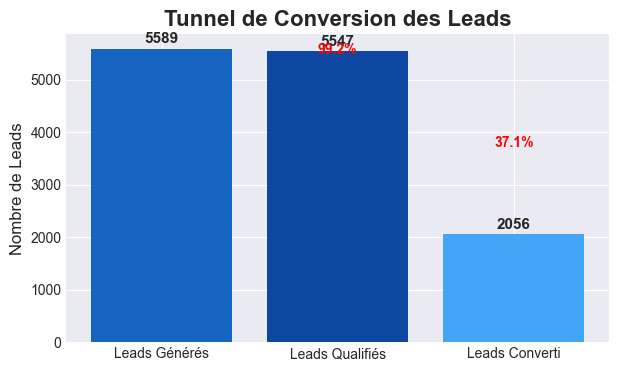

In [395]:
labels = ['Leads Générés', 'Leads Qualifiés', 'Leads Converti']
values = [Nbre_leads_genere, Nbre_leads_genere * (Taux_qualification_leads/100), Nbre_leads_converti]
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=['#1565C0', '#0D47A1', '#42A5F5'])
plt.ylabel('Nombre de Leads', fontsize=12)
plt.title('Tunnel de Conversion des Leads', fontsize=16, fontweight='bold')
for i, v in enumerate(values):
    plt.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    if i > 0:
        taux = (values[i]/values[i-1])*100
        plt.text(i, (v + values[i-1])/2, f'{taux:.1f}%', ha='center', va='center', fontsize=10, color='red', fontweight='bold')

In [186]:
Marketing["chiffre d'affaires mensuel déclaré"] = pd.to_numeric(Marketing["chiffre d'affaires mensuel déclaré"], errors="coerce")
Marketing["stock moyen"] = pd.to_numeric(Marketing["stock moyen"], errors="coerce")

Marketing_CA_médiane = Marketing["chiffre d'affaires mensuel déclaré"].median()
Marketing_stock_médiane = Marketing["stock moyen"].median()

In [187]:
# Taux de valeurs manquantes dans les colonnes qui nous permettrons d'analyser nos leads qualifiés
print("Valeurs manquantes")
Marketing[["présence d'une entreprise","présence d'un GTIN","taille du catalogue produits déclarée","chiffre d'affaires mensuel déclaré","stock moyen"]].isnull().sum()/len(Marketing)*100

Valeurs manquantes


présence d'une entreprise                98.425479
présence d'un GTIN                       98.300233
taille du catalogue produits déclarée     0.000000
chiffre d'affaires mensuel déclaré        0.339953
stock moyen                               0.339953
dtype: float64

In [188]:
# Identifions les leads qui pourrais etre qualifié (donc des personnes qui ont de fortes chances de faire des achats)
# Ayant un taux fort de valeurs manquantes dans "présence d'une entreprise" et "présence d'un GTIN", on ne sélectionnera pas ces colonnes...
def Leads_qualified(z, t, i):
    probabilite = 0

    if pd.notna(z) and z >= 500:
        probabilite += 0.2

    if pd.notna(t) and t >= Marketing_CA_médiane:
        probabilite += 0.2

    if pd.notna(i) and i >= Marketing_stock_médiane:
        probabilite += 0.2

    return probabilite
    
Marketing["lead_score"] = Marketing.apply(
    lambda row: Leads_qualified(
        row["taille du catalogue produits déclarée"],
        row["chiffre d'affaires mensuel déclaré"],
        row["stock moyen"]
    ),
    axis=1
)

Marketing['lead_qualified'] = Marketing['lead_score'].apply(lambda x: "qualified" if x>=0.4 else "Not qualified")

Taux_qualification_leads = (len(Marketing['lead_qualified'][Marketing['lead_qualified'] == "qualified"])/len(Marketing['lead_qualified']))*100

print(f"•	Taux de qualification des leads : {round(Taux_qualification_leads, 2)}%")

•	Taux de qualification des leads : 99.25%


In [189]:
Source_leads_performant = Marketing[(Marketing.lead_qualified=="qualified") & (Marketing.customer_unique_id.isna()==False)].groupby('type de prospect')['lead_qualified'].size()

Marketing["Date de gain"] = pd.to_datetime(Marketing["Date de gain"], format="%Y-%m-%d")
Marketing["date du premier contact"] = pd.to_datetime(Marketing["date du premier contact"], format="%Y-%m-%d", errors="coerce")

Marketing["Delai_moyen_conversion"] = Marketing["Date de gain"] - Marketing["date du premier contact"]

Delai_moyen_conversion = Marketing["Delai_moyen_conversion"].mean()

volume_leads_segment = Marketing.groupby("segment d'activité")["type de prospect"].count()

origine_leads = Marketing[Marketing["type de prospect"] == "online_medium"].groupby("origine")["type de prospect"].count()

print(f"•	Sources de leads les plus performantes : \n{Source_leads_performant.sort_values(ascending=False).head(1)}\n")
print(f"•	Délai moyen conversion lead → client : {Delai_moyen_conversion}\n")
print(f"•	Volume de leads par segment business: \n{volume_leads_segment.sort_values(ascending=False)}\n")
print(f"•   Origine des leads du marketing en ligne: \n {origine_leads.sort_values(ascending=False)}")

•	Sources de leads les plus performantes : 
type de prospect
online_medium    815
Name: lead_qualified, dtype: int64

•	Délai moyen conversion lead → client : 24 days 12:09:49.443447037

•	Volume de leads par segment business: 
segment d'activité
health_beauty                      882
watches                            609
household_utilities                594
home_decor                         522
construction_tools_house_garden    360
audio_video_electronics            308
pet                                306
car_accessories                    214
bed_bath_table                     207
sports_leisure                     190
bags_backpacks                     151
computers                          151
home_appliances                    145
toys                               138
food_supplement                    123
books                              111
home_office_furniture               93
small_appliances                    75
fashion_accessories                 73
food_drink  

In [191]:
print("Apport des clients provenant des données marketing:")

CA_leads_client = Marketing["Montant_paiement"][(Marketing["type de prospect"].isna()==False) & (Marketing["Status_commande"]!="canceled") & (Marketing['Status_commande']!="unavailable")].sum()

Taux_CA_leads_client = (CA_leads_client / CA)*100

panier_moyen_leads_clients = Marketing["Montant_paiement"][(Marketing["type de prospect"].isna()==False) & (Marketing["Status_commande"]!="canceled") & (Marketing['Status_commande']!="unavailable")].mean()
panier_mediane_leads_clients = Marketing["Montant_paiement"][(Marketing["type de prospect"].isna()==False) & (Marketing["Status_commande"]!="canceled") & (Marketing['Status_commande']!="unavailable")].median()

print(f"Les leads convertis en clients ont généré {round(CA_leads_client,2)} euros de Chiffre d'Affaire, soit {round(Taux_CA_leads_client,2)}% du Chiffre d'Affaire total...")
print(f"Panier moyen des leads convertis en clients: {round(panier_moyen_leads_clients,2)} euros...")

if panier_mediane_leads_clients < panier_moyen_leads_clients:
    print("La repartition est asymétrique vers la droite...")
elif panier_mediane_leads_clients > panier_moyen_leads_clients:
    print("La repartition est asymétrique vers la gauche...")
else:
    print("La repartition est symétrique...")

Apport des clients provenant des données marketing:
Les leads convertis en clients ont généré 375046.78 euros de Chiffre d'Affaire, soit 2.38% du Chiffre d'Affaire total...
Panier moyen des leads convertis en clients: 182.68 euros...
La repartition est asymétrique vers la droite...


### ***ANALYSE DU MARKETING***

Les actions marketing d'OLIST ont permise de générer 5589 leads soit 5589 potentiels clients, donc statistiquement 99.25% d'eux étaient près à devenir des clients: ils étaient qualifiés. Mais seulement 36.79% d'eux sont devenus des clients soit 2056 personnes sur 5589.

On note que c'est grace aux différentes méthodes qu'ils ont employés en ligne notamment le reférencement payant, recherche organique, ... qu'ils ont eu le plus de clients, environ 815 clients grace aux opérations en lignes (on peut imaginer les publicités, les collaborations,...),...

D'après cette analyse, on comprend aussi que des clients sont intéressé par les domaines de la santé, beauté,..., ce qui nous permet d'émettre une hypothèse, le marketing d'OLIST impacte sur les femmes et personnes se souciant de leurs santés en majeure partie...

Le délai moyen pour qu'un potentiel client effectue ses achats est d'une journée.

Les leads convertis en client ont généré 2.38% du chiffre d'affaire total, ce qui n'est pas énorme en soit... pour un panier moyen de 182.68 euros contre 153.44 euros de clients non leads

A ce niveau de l'analyse, une hypothèse se présente:

    Le marketing d'OLIST attire en majeure partie les femmes pour son domaine de la beauté ainsi que la santé, mais certaines d'entre elles ne contribuent pas en tant que tel au CA d'OLIST (montants faibles): compréhension en quelques mots: attirance simple pour une contribution légère..., cela est affirmé par l'asymétrie des montants (moyenne éloignée de la médiane...)

### ***f.KPI VENDEURS***

In [ ]:
Vendeurs["Montant"] = Vendeurs["price"]+Vendeurs["freight_value"]
Vendeurs = pd.merge(Vendeurs, Ventes, on="order_id", how="left")
Vendeurs.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,Montant,Echéancier_paiement,Type_paiement,Sequence_paiement,Montant_paiement,customer_id,Status_commande,Date_achat_commande,Date_approbation_commande,Date_livraison_transporteur,Date_livraison_estime,Mois_ventes,Jour_ventes,Annee_Vente,Trimestre
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19,58.90,13.29,27277,volta redonda,SP,72.19,2.0,credit_card,1.0,72.19,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13,2017-09-13,2017-09-19,2017-09-29,9.0,13.0,2017.0,3.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03,239.90,19.93,3471,sao paulo,SP,259.83,3.0,credit_card,1.0,259.83,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26,2017-04-26,2017-05-04,2017-05-15,4.0,26.0,2017.0,2.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18,199.00,17.87,37564,borda da mata,MG,216.87,5.0,credit_card,1.0,216.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14,2018-01-14,2018-01-16,2018-02-05,1.0,14.0,2018.0,1.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15,12.99,12.79,14403,franca,SP,25.78,2.0,credit_card,1.0,25.78,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08,2018-08-08,2018-08-10,2018-08-20,8.0,8.0,2018.0,3.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13,199.90,18.14,87900,loanda,PR,218.04,3.0,credit_card,1.0,218.04,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04,2017-02-04,2017-02-16,2017-03-17,2.0,4.0,2017.0,1.0


In [206]:
Vendeurs = Vendeurs.drop_duplicates()
Nbre_vendeur_actifs = len(Vendeurs)
CA_par_vendeur = Vendeurs[(Vendeurs["Status_commande"]!="canceled")&(Vendeurs["Status_commande"]!="unavailable")].groupby("seller_id").agg({
    "Montant_paiement": 'sum',
    "seller_id": "value_counts"
})
CA_par_vendeur.rename(columns={
                "seller_id":"Nombre de ventes", 
                "Montant_paiement": "CA"
}, inplace=True)

CA_par_vendeur['Participation au CA global(%)'] = (CA_par_vendeur["CA"]/CA)*100

print(f"•	Nombre de vendeurs actifs : {Nbre_vendeur_actifs}")
print(f"•	Chiffre d’affaires et volume de vente par vendeur : \n")
CA_par_vendeur.sort_values(by="CA", ascending=False)

•	Nombre de vendeurs actifs : 117601
•	Chiffre d’affaires et volume de vente par vendeur : 



,CA,Nombre de ventes,Participation au CA global(%)
seller_id,,,
7c67e1448b00f6e969d365cea6b010ab,507166.91,1452,3.222330
1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,1462,1.958316
4a3ca9315b744ce9f8e9374361493884,301064.61,2131,1.912841
1f50f920176fa81dab994f9023523100,290185.92,2006,1.843722
53243585a1d6dc2643021fd1853d8905,284903.08,437,1.810157
...,...,...,...
ad14615bdd492b01b0d97922e87cb87f,19.21,1,0.000122
702835e4b785b67a084280efca355756,18.56,1,0.000118
4965a7002cca77301c82d3f91b82e1a9,16.36,1,0.000104


In [ ]:
Vendeurs["shipping_limit_date"] = pd.to_datetime(Vendeurs["shipping_limit_date"], format="%Y-%m-%d", errors="coerce")
Vendeurs["Temp_traitement_vendeur"] = Vendeurs["shipping_limit_date"] - Vendeurs["Date_achat_commande"]

Temp_moyen_traitement = Vendeurs.groupby("seller_id").agg({
    "Temp_traitement_vendeur" : 'mean',
    "Montant_paiement": 'sum',
    "seller_id": "value_counts"
})

Temp_moyen_traitement.rename(columns={
                "seller_id":"Nombre de ventes", 
                "Montant_paiement": "CA"
}, inplace=True)

print(f"•	Top vendeurs (performance globale) : \n")
Temp_moyen_traitement.sort_values(by="CA",ascending=False)

•	Top vendeurs (performance globale) : 



,Temp_traitement_vendeur,CA,Nombre de ventes
seller_id,,,
7c67e1448b00f6e969d365cea6b010ab,14 days 02:14:52.561983471,507166.91,1452
1025f0e2d44d7041d6cf58b6550e0bfa,6 days 17:59:30.451436388,308222.04,1462
4a3ca9315b744ce9f8e9374361493884,5 days 21:36:12.151898734,301245.27,2133
1f50f920176fa81dab994f9023523100,6 days 03:34:25.338645418,290253.42,2008
53243585a1d6dc2643021fd1853d8905,6 days 08:47:13.867276887,284903.08,437
...,...,...,...
ad14615bdd492b01b0d97922e87cb87f,5 days 00:00:00,19.21,1
702835e4b785b67a084280efca355756,4 days 00:00:00,18.56,1
4965a7002cca77301c82d3f91b82e1a9,5 days 00:00:00,16.36,1


In [213]:
Nbre_vente_moy = (Vendeurs['seller_id'].value_counts()).mean()

print(f"Nombre de vente moyenne : {int(Nbre_vente_moy)} ventes...")

Nombre de vente moyenne : 38 ventes...


In [208]:
Vendeurs_reguliers = Vendeurs["seller_id"].value_counts()

print(f"•	Vendeurs les plus réguliers :\n")
Vendeurs_reguliers.sort_values(ascending=False).head()

•	Vendeurs les plus réguliers :



seller_id
4a3ca9315b744ce9f8e9374361493884    2133
6560211a19b47992c3666cc44a7e94c0    2122
1f50f920176fa81dab994f9023523100    2008
cc419e0650a3c5ba77189a1882b7556a    1847
da8622b14eb17ae2831f4ac5b9dab84a    1639
Name: count, dtype: int64

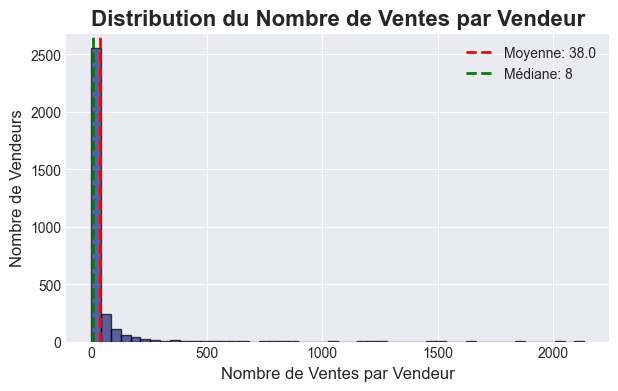

In [392]:
ventes_par_vendeur = Vendeurs['seller_id'].value_counts()
plt.figure(figsize=(7, 4))
plt.hist(ventes_par_vendeur, bins=50, color='#1A237E', alpha=0.7, edgecolor='black')
plt.axvline(ventes_par_vendeur.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {ventes_par_vendeur.mean():.1f}')
plt.axvline(ventes_par_vendeur.median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {ventes_par_vendeur.median():.0f}')
plt.xlabel('Nombre de Ventes par Vendeur', fontsize=12)
plt.ylabel('Nombre de Vendeurs', fontsize=12)
plt.title('Distribution du Nombre de Ventes par Vendeur', fontsize=16, fontweight='bold')
plt.legend()

### ***ANALYSES VENDEURS***

On enregistre 117601 vendeurs au total dans OLIST qui ont contribué au CA de l'entreprise dont le vendeur ayant un CA max dans la CA de l'entreprise est de 3% avec 1452 ventes effectuées, soit 507166.91 euros avec un temp de traitement de la commande de 14 jours, on peut supposer qu'il s'agissait d'un colis plutot important et volumineux à une distance plutot considérable, peut etre d'un pays à un autre ou un continent à un autre.

La moyenne des ventes effectuées par les vendeurs étant de 38, on peut observer qu'il y a une asymétrie à droite, il y a un écart considérable. On peut donc émettre une hypothèse, OLIST a des vendeurs qui y sont depuis une tres grande période par rapport à d'autres, cela justifierais parfaitement cet asymétrie.

### ***RECAPITULATIF DE DIFFERENTS POINTS QUI IMPACTENT LA PERFORMANCE D'OLIST***

a) LA LOGISTIQUE

        Un retard plutot important entre la commande et l'expédition de la commande meme si la commande est livrée en majeure partie avant la date estimée de livraison...

b) LES COMMANDES

        Il y a plus de 600 commandes qui n'ont pas été prise en compte à cause d'un stock insuffisant,...
        Il y a aussi plus de 600 commandes annulées, et j'ai énuméré plusieurs hypothèses par rapport à cela...

c) LE MARKETING

        Le marketing d'OLIST n'est pas percutant, cela attire plus ce qu'on va dire Clients pas importants, donc des clients faciles qui n'ont pas vraiment d'impact dans le CA global, et en plus, le % de conversion des leads en clients n'est pas mal mais à surveiller, car les données peuvent etre biaisées au vue d'une grande quantité de données manquantes qui auraient pu pousser l'analyse...

d) LES PRODUITS

        Il y a des produits qui ne sont pas du tout appréciés par les clients d'OLIST, ils reçoivent en masse des mauvaises notes, ce qui pourrait faire comprendre que le produit est de qualité inférieure par rapport à celle du marché, ou encore trop chère pour la qualité proposée...

e) CLIENTS & SATISFACTION CLIENT

        Le taux de fidélisation des clients étant inférieur à 8% revèle qu'après leur premier achat en majorité, les clients ne sont pas vraiment content de leurs produits recus ou ils ne répondent pas vraiment aux besoins attendus... 

### ***MESURE DE LA PERFORMANDE D'OLIST***

In [261]:
Performance_globale = {
    "commerciale": 40,
    "satisfaction_client": 30,
    "Logistique": 20,
    "Marketing": 10
}

In [370]:
Commercial = 0

Dict_commercial = {
    "CA": [20000000, 20],
    "CA_Mensuel": [1700000, 10],
    "CA_jour": [600000, 10],
    "Nbre_commandes": [110000, 10],
    "Nbres_ventes": [100000, 10],
    "Panier_moyen": [200, 10],
    "Commandes_annules": [200, 10],
    "Commandes_indispo": [200, 10],
    "Nbre_retard": [0, 10],
}

liste_commerciale = list(Dict_commercial.keys())
perf_com_glob = 0

def Performance_commerciale(CA, CA_Mensuel, CA_jour, Nbre_commandes, Nbres_ventes, Panier_moyen, Commandes_annules, Commandes_indispo, Nbre_retard):
    Commercial = 0
    global perf_com_glob
    for n, t in zip(liste_commerciale, (CA, CA_Mensuel, CA_jour, Nbre_commandes, Nbres_ventes, Panier_moyen, Commandes_annules, Commandes_indispo, Nbre_retard)):
        for j,i in enumerate(Dict_commercial[n]):
            if j==0:
                if i > 0 and t < 0 or i<0 and t > 0:
                    continue
                else:
                    if t >= i:
                        Commercial += Dict_commercial[n][1]
                    else:
                        Commercial += (Dict_commercial[n][1] * (t/i)*100)/100
    perf_com_glob = (Performance_globale["commerciale"]*Commercial)/100

    print(f" --- Performance commerciale (Vente) : {round(Commercial,2)}% correspondant à {round(perf_com_glob,2)}% / {Performance_globale["commerciale"]}% sur la performance globale...")
    return Commercial, perf_com_glob

In [364]:
satisfaction = 0

Dict_satisfaction = {
    "Nbre_Clients_unique": [100000, 10],
    "Nbre_Clients_recurrents" : [10000, 10],
    "Taux_fidelisation": [70, 20],
    "Taux_churn": [30, 10],
    "note_moyenne":[4, 20],
    "Pourcent_avis_positifs": [95, 10],
    "Pourcent_avis_negatifs": [5, 10],
    "Delai_moyen_groupe_livraison": [3, 10]
}

liste_satisfaction = list(Dict_satisfaction.keys())
perf_satis_glob = 0

def Performance_Satisfaction(Nbre_Client_unique, Nbre_Clients_recurrents, Taux_fidelisation, Taux_churn, note_moyenne, pourcentage_avis_positif, pourcentage_avis_negatif, Delai_livraion_moyen):
    satisfaction = 0
    global perf_satis_glob
    for n, t in zip(liste_satisfaction, (Nbre_Client_unique, Nbre_Clients_recurrents, Taux_fidelisation, Taux_churn, note_moyenne, pourcentage_avis_positif, pourcentage_avis_negatif, Delai_livraion_moyen)):
        for j,i in enumerate(Dict_satisfaction[n]):
            if j==0:
                if i > 0 and t < 0 or i < 0 and t > 0:
                    continue
                else:
                    if t >= i:
                        satisfaction += Dict_satisfaction[n][1]
                    else:
                        satisfaction += (Dict_satisfaction[n][1] * (t/i)*100)/100
    perf_satis_glob = (Performance_globale["satisfaction_client"]*satisfaction)/100

    print(f" --- Performance satisfaction client + clients : {round(satisfaction,2)}% correspondant à {round(perf_satis_glob,2)}% / {Performance_globale["satisfaction_client"]}% sur la performance globale...")
    return satisfaction, perf_satis_glob

In [363]:
logistique = 0

Dict_logistique = {
    "Produit_plus_vendus": [15000, 10],
    "Produit_moin_vendus" : [1000, 10],
    "Revenus_produit_meilleur": [3500000, 10],
    "Meilleure_note": [5, 20],
    "Basse_note": [1, 20],
    "CA_vendeur_top":[1000000, 10],
    "Nbre_vente_vendeur_top": [1500, 10],
    "Temps_traitement_vendeur": [3, 10]
}

perf_logis_glob = 0
liste_logistique = list(Dict_logistique.keys())

def Performance_logistique(Produit_plus_vendus, Produit_moin_vendus, Revenus_produit_meilleur, Meilleure_note, Basse_note, CA_vendeur_top, Nbre_vente_vendeur_top, Temps_traitement_vendeur):
    logistique = 0
    global perf_logis_glob
    for n, t in zip(liste_logistique, (Produit_plus_vendus, Produit_moin_vendus, Meilleure_note, Basse_note, CA_vendeur_top, Nbre_vente_vendeur_top, Temps_traitement_vendeur)):
        for j,i in enumerate(Dict_logistique[n]):
            if j==0:
                if i > 0 and t < 0 or i < 0 and t > 0:
                    continue
                else:
                    if t >= i:
                        logistique += Dict_logistique[n][1]
                    else:
                        logistique += (Dict_logistique[n][1] * (t/i)*100)/100
    perf_logis_glob = (Performance_globale["Logistique"]*logistique)/100

    print(f" --- Performance logistique: {round(logistique,2)}% correspondant à {round(perf_logis_glob,2)}% / {Performance_globale["Logistique"]}% sur la performance globale...")
    return logistique, perf_logis_glob

In [368]:
Marketing = 0

Dict_Marketing = {
    "leads_genere": [8000, 20],
    "conversion_leads" : [70, 30],
    "Qualification": [99, 20],
    "CA_genere_leads": [2000000, 30]
}

liste_Marketing = list(Dict_Marketing.keys())
perf_Marketing_glob = 0
def Performance_Marketing(leads_genere, conversion_leads, Qualification, CA_genere_leads):
    global perf_Marketing_glob
    Marketing = 0
    for n, t in zip(liste_Marketing, (leads_genere, conversion_leads, Qualification, CA_genere_leads)):
        for j,i in enumerate(Dict_Marketing[n]):
            if j==0:
                if i > 0 and t < 0 or i < 0 and t > 0:
                    continue
                else:
                    if t >= i:
                        Marketing += Dict_Marketing[n][1]
                    else:
                        Marketing += (Dict_Marketing[n][1] * (t/i)*100)/100
    perf_Marketing_glob = (Performance_globale["Marketing"]*Marketing)/100

    print(f" --- Performance marketing : {round(Marketing,2)}% correspondant à {round(perf_Marketing_glob,2)}% / {Performance_globale["Marketing"]}% sur la performance globale...")
    return Marketing, perf_Marketing_glob

In [389]:
Performance_commerciale(CA, CA_Mensuel[5], Commandes_periode_jour_vendus.loc[24, 'Montant_paiement'],Nbre_commande, Nbre_produits, Panier_moyen, commandes_annulees, commandes_stock_indispo, Nbre_commande_livre_retard)

Performance_Satisfaction(Nbre_Clients_unique, Nbre_Clients_recurrents, Taux_fidelisation, Taux_churn, int(Note_moyenne), Pourcent_avis_positifs, Pourcent_avis_negatifs, Delai_moyen_groupe.iloc[4].days)

Performance_logistique(Produits_vendus_categorie["cama_mesa_banho"], Produits_vendus_categorie["seguros_e_servicos"], Revenus_produits["cama_mesa_banho"], Categorie_mieux_note["agro_industria_e_comercio"], Categorie_moins_note["fashion_esporte"], CA_par_vendeur.loc[CA_par_vendeur["Nombre de ventes"] == 1452,"CA"].iloc[0], 1452, Temp_moyen_traitement.loc[Temp_moyen_traitement["Nombre de ventes"] == 1452, "Temp_traitement_vendeur"].iloc[0].days) 

Performance_Marketing(Nbre_leads_genere, Taux_conversion, Taux_qualification_leads, CA_leads_client)

Perfo_globale = perf_Marketing_glob + perf_logis_glob + perf_satis_glob + perf_com_glob

print(f"\nLa performance globale d'OLIST est de {round(Perfo_globale,2)}%")

if Perfo_globale>=0 and Perfo_globale<=40:
    print("Remarque: Olist a une faible performance...")
elif Perfo_globale>40 and Perfo_globale<=70:
    print("Remarque: Olist a une performance moyenne...")
elif Perfo_globale>70 and Perfo_globale<=85:
    print("Remarque: Olist a une bonne performance...")
else:
    print("Remarque: Olist a une excellente performance...")

 --- Performance commerciale (Vente) : 93.34% correspondant à 37.34% / 40% sur la performance globale...
 --- Performance satisfaction client + clients : 67.66% correspondant à 20.3% / 30% sur la performance globale...
 --- Performance logistique: 32.61% correspondant à 6.52% / 20% sur la performance globale...
 --- Performance marketing : 55.36% correspondant à 5.54% / 10% sur la performance globale...

La performance globale d'OLIST est de 69.69%
Remarque: Olist a une performance moyenne...


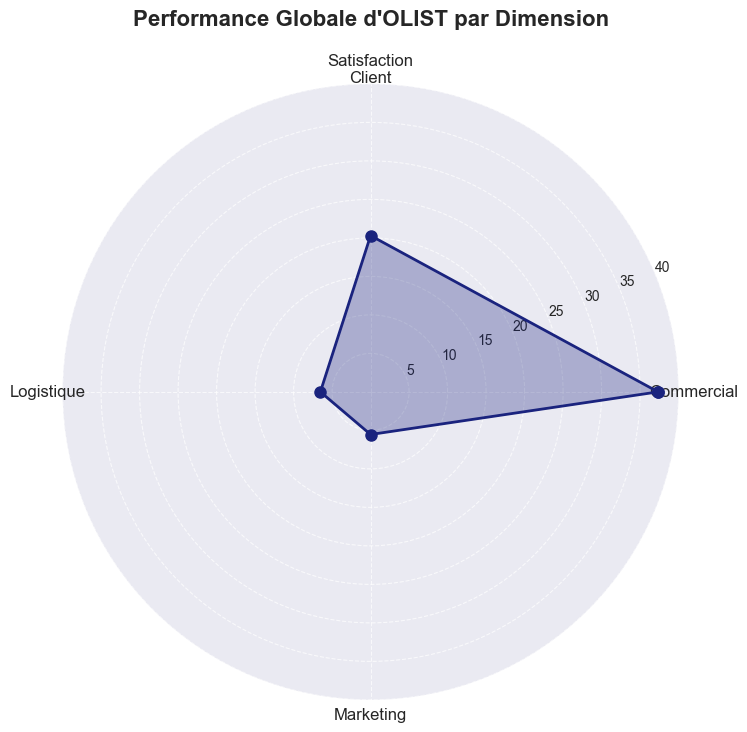

In [ ]:
from math import pi

categories = ['Commercial', 'Satisfaction\nClient', 'Logistique', 'Marketing']
values = [perf_com_glob, perf_satis_glob, perf_logis_glob, perf_Marketing_glob]
max_score = Performance_globale['commerciale']

N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

values += values[:1]
categories += categories[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')
ax.plot(angles, values, linewidth=2, linestyle='solid', color='#1A237E', marker='o', markersize=8)
ax.fill(angles, values, alpha=0.3, color='#1A237E')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories[:-1], fontsize=12)
ax.set_ylim(0, max_score)
ax.set_title('Performance Globale d\'OLIST par Dimension', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, linestyle='--', alpha=0.7)

### ***DIFFERENTES PROPOSITIONS POUR AMELIORER LA PERFORMANDE D'OLIST***

### ***AMELIORATION DE LA PERFORMANCE COMMERCIALE***

A --- REDUIRE LES ANNULATIONS DE COMMANDES

    1. Mettre en place un système de rappel pour les paniers abandonnés
    2. Proposer des paiements en 2x ou 3x sans frais pour les gros montants
    3. Améliorer la transparence sur les délais de livraison

B ---  OPTIMISER LA GESTION DES STOCKS

    Mettre en place des alertes de stock minimum (seuil à 20 unités)
    Dropshipping pour les produits en rupture
    Précommande avec délai annoncé

### ***AMELIORATION DE LA SATISFACTION CLIENT***

A --- Réduire les délais de livraison

    Créer un partenariat avec les transporteurs de la localité
    Créer un point de distribution régional
    
B --- Améliorer le programme de fidélisation

    Email marketing : campagne de réactivation ("Vous nous manquez !")
    Bon de réduction : 15% sur la prochaine commande
    Programme VIP : avantages exclusifs (livraison gratuite, accès anticipé,...)

C. Améliorer la gestion des avis négatifs

    Analyser les commentaires et identifier les causes récurrentes

### ***AMELIORATION DE LA LOGISTIQUE***

A --- Optimisation des frais de port

    Négociation avec transporteurs
    Livraison par lot pour zones reculées
    Standardisation des emballages

B --- Améliorer le temps de traitement

    Pénalités pour les vendeurs en retard
    Bonus pour les vendeurs rapides

### ***AMELIORATION DU MARKETING***

A --- Optimiser le tunnel de conversion en ciblant les bons segments

    Health_beauty : Cible principale (882 leads)
    Watches : Panier moyen élevé


### ***FIN***